In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize, linprog
import matplotlib.pyplot as plt

## Setup, Handoff and Model Conventions

### Load Research Handoff and Portfolio Parameters

In [2]:
# LOAD HANDOFF

BL_HANDOFF = pd.read_pickle("CQF_BL_Handoff.pkl")

CONFIG = BL_HANDOFF["config"]

ASSETS = list(CONFIG["ASSETS"])

ROLLING_WINDOW = int(CONFIG["ROLLING_WINDOW"])

REBALANCE_FREQUENCY_MONTHS = int(CONFIG["REBALANCE_FREQUENCY_MONTHS"])

TOP_N = int(CONFIG["TOP_N"])

BOTTOM_N = int(CONFIG.get("BOTTOM_N", 3))

TAU = float(CONFIG["TAU"])

MAX_WEIGHT = float(CONFIG["MAX_WEIGHT"])

# IMPLEMENTATION PARAMETERS

MIN_WEIGHT = 0.00

ANNUALIZATION_FACTOR = 12

TRANSACTION_COST_BPS = 10


# TURNOVER-AWARE BL

BL_TURNOVER_PENALTY = (ANNUALIZATION_FACTOR/ REBALANCE_FREQUENCY_MONTHS * TRANSACTION_COST_BPS / 10000)

print("BL turnover penalty:",BL_TURNOVER_PENALTY)

CVAR_ALPHA = 0.95

# LOAD REQUIRED DATA

asset_monthly_prices = (
    BL_HANDOFF["asset_monthly_prices"].copy().sort_index().reindex(columns=ASSETS))

asset_monthly_returns = (BL_HANDOFF["asset_monthly_returns"].copy().sort_index().reindex(columns=ASSETS))

asset_monthly_excess_returns = (BL_HANDOFF["asset_monthly_excess_returns"].copy().sort_index().reindex(columns=ASSETS))

composite_score = (BL_HANDOFF["composite_score"].copy().sort_index().reindex(columns=ASSETS))

spread_panel_3m = (BL_HANDOFF["spread_panel_3m"].copy().sort_index())

rf_monthly = (BL_HANDOFF["rf_monthly"].copy().sort_index())

rf_monthly.name = "RF"

# FIXED MODEL ANCHORS

# Fixed Black-Litterman risk-aversion coefficient
FIXED_DELTA = 3.0

# Fixed annualized return per one unit of composite-score gap
FIXED_VIEW_SCALE_K = float(
    CONFIG.get("VIEW_SCALE_K", 0.025)
)

print("Assets:", len(ASSETS))
print("Latest return date:", asset_monthly_returns.index.max())
print("Latest signal date:", composite_score.index.max())
print("Fixed delta:", FIXED_DELTA)
print("Fixed view-scale k:", FIXED_VIEW_SCALE_K)


# CQF STATIC RISK-AVERSION PROFILES

RISK_AVERSION_PROFILES = {
    "Trustee": 2.0 * FIXED_DELTA,
    "Market": FIXED_DELTA,
    "Kelly": 0.5 * FIXED_DELTA
}

display(pd.Series(RISK_AVERSION_PROFILES,name="RiskAversion"))

BL turnover penalty: 0.004
Assets: 12
Latest return date: 2026-07-31 00:00:00
Latest signal date: 2026-07-31 00:00:00
Fixed delta: 3.0
Fixed view-scale k: 0.025


Trustee    6.0
Market     3.0
Kelly      1.5
Name: RiskAversion, dtype: float64

In [3]:
# LOAD FACTOR DATA FROM NOTEBOOK 1

FACTOR_COLUMNS = ["Equity","Duration","Credit","Commodity"]


factor_monthly_returns = (BL_HANDOFF["factor_monthly_returns"].copy())


factor_monthly_excess_returns = (BL_HANDOFF["factor_monthly_excess_returns"].copy())


factor_etf_prices = (BL_HANDOFF["factor_etf_prices"].copy())


FACTOR_DEFINITIONS = (
    CONFIG.get(
        "FACTOR_DEFINITIONS",
        {}
    )
)

## Static Decision Date and Estimation Framework

In [4]:
# Get the most recent observations window available as of the specified date
def get_estimation_window(returns,as_of_date,window=60):
    historical_returns=(returns.loc[:pd.Timestamp(as_of_date)].dropna().tail(window).copy())
    
    if len(historical_returns) < window:
        raise ValueError(f"Only {len(historical_returns)} clean observations available; {window} required")
    
    return historical_returns

In [5]:
REBALANCE_FREQUENCY_MONTHS

3

In [6]:
# Latest signal date for which complete subsequent holding period exists
def get_latest_complete_rebalance_date(monthly_returns,composite_score,assets,horizon=3):
    
    candidate_dates=(composite_score.index.intersection(monthly_returns.index).sort_values())
    
    valid_dates=[]
    
    for date in candidate_dates:
        scores=(composite_score.loc[date].reindex(assets))
        
        if scores.isna().any():
            continue
        
        future_returns=(monthly_returns.loc[monthly_returns.index > date, assets].head(horizon))
        
        if ((len(future_returns) == horizon) and future_returns.notna().all().all()):
            valid_dates.append(date)
    
    if not valid_dates:
        raise ValueError("No date has a complete forward holding period ")
    
    return max(valid_dates)

In [7]:
# Get latest valid date for static analysis
STATIC_AS_OF_DATE=(get_latest_complete_rebalance_date(asset_monthly_excess_returns,composite_score,ASSETS,REBALANCE_FREQUENCY_MONTHS))
STATIC_AS_OF_DATE

Timestamp('2026-04-30 00:00:00')

In [8]:
# FIXED VIEW-SCALE PARAMETER

k_static = FIXED_VIEW_SCALE_K


k_static_info = {"method":"fixed_anchor",
                 "k_annual":FIXED_VIEW_SCALE_K}


static_setup = pd.Series({"Static decision date":STATIC_AS_OF_DATE,
                          "Holding horizon months":REBALANCE_FREQUENCY_MONTHS,
                          "Fixed annualized k":FIXED_VIEW_SCALE_K,
                          "Fixed delta":FIXED_DELTA})

static_setup

Static decision date      2026-04-30 00:00:00
Holding horizon months                      3
Fixed annualized k                      0.025
Fixed delta                               3.0
dtype: object

## Covariance Estimation and Numerical Stability

In [9]:
# Estimate annualized covariance matrix using last 60 months observations
def estimate_covariance(returns, as_of_date, window=60, method="ledoit_wolf", annualization_factor=12):
    estimation_returns=(get_estimation_window(returns,as_of_date,window))
    assets=list(estimation_returns.columns)
    
    if method=="sample":
        monthly_cov=(estimation_returns.cov())
        shrinkage=np.nan
    
    elif method=="ledoit_wolf":
        lw=LedoitWolf().fit(estimation_returns.values)
        
        monthly_cov=pd.DataFrame(lw.covariance_,index=assets,columns=assets)
        shrinkage=float(lw.shrinkage_)
    
    annual_cov=(monthly_cov * annualization_factor)
    
    res={"as_of_date":pd.Timestamp(as_of_date),
        "window":len(estimation_returns),
        "start_date":estimation_returns.index.min(),
        "end_date":estimation_returns.index.max(),
        "method":method,
        "shrinkage":shrinkage}
    
    return annual_cov, res

In [10]:
# Covariance Diagnostics
def covariance_diagnostics(cov_matrix):
    values=cov_matrix.values
    eigenvalues=np.linalg.eigvalsh(values)
    
    return {"Min_Eigenvalue":eigenvalues.min(),
           "Max_Eigenvalue":eigenvalues.max(),
           "Condition_Number": np.linalg.cond(values),
           "Positive_Definite":bool(np.all(eigenvalues > 0))}

In [11]:
# Sample Cov Matrix
sample_cov, sample_info=(estimate_covariance(asset_monthly_excess_returns,STATIC_AS_OF_DATE,ROLLING_WINDOW,"sample"))

# LW Cov Matrix
lw_cov, lw_info=(estimate_covariance(asset_monthly_excess_returns,STATIC_AS_OF_DATE,ROLLING_WINDOW,"ledoit_wolf"))



In [12]:
covariance_comparison=pd.DataFrame({"Sample": covariance_diagnostics(sample_cov),
                                   "Ledoit_Wolf":covariance_diagnostics(lw_cov)})

covariance_comparison

,Sample,Ledoit_Wolf
Min_Eigenvalue,0.000052,0.001491
Max_Eigenvalue,0.141274,0.129857
Condition_Number,2742.537755,87.095907
Positive_Definite,True,True


**Covariance result.** Both covariance matrices are positive definite, but the sample estimate is poorly conditioned. Its condition number is approximately 2,742 compared with only about 87 for the Ledoit–Wolf estimate. 

The large improvement in conditioning is important because the covariance matrix enters every portfolio optimiser. Ledoit–Wolf shrinkage is therefore used as the main covariance estimator throughout both the static and walk-forward analysis.

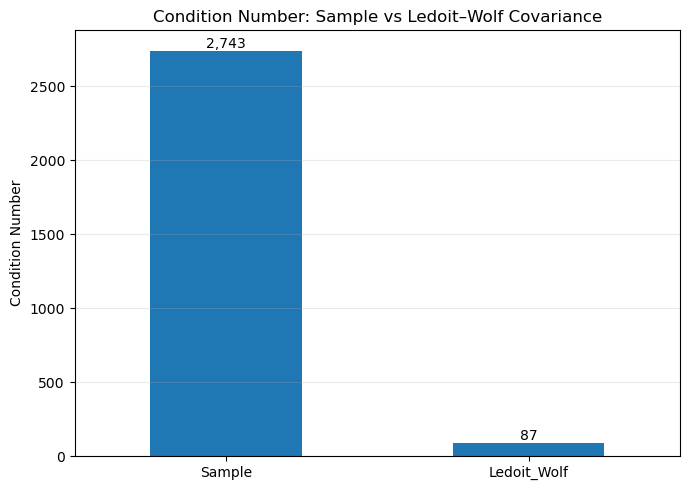

In [13]:
# Covariance Condition-Number Comparison

condition_number_plot = (covariance_comparison.loc["Condition_Number", ["Sample", "Ledoit_Wolf"]].astype(float))

ax = condition_number_plot.plot(kind="bar",figsize=(7, 5))

ax.set_title("Condition Number: Sample vs Ledoit–Wolf Covariance")

ax.set_ylabel("Condition Number")
ax.set_xlabel("")

ax.grid(axis="y",alpha=0.25)

for patch in ax.patches:
    height = patch.get_height()

    ax.annotate(f"{height:,.0f}",(patch.get_x() + patch.get_width()/2, height),ha="center",va="bottom")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
vol_comparison=pd.DataFrame({"Sample_Vol":np.sqrt(np.diag(sample_cov)),
                            "Ledoit_Wolf_Vol":np.sqrt(np.diag(lw_cov))}, index=sample_cov.index)
vol_comparison

,Sample_Vol,Ledoit_Wolf_Vol
Ticker,,
SPY,0.156690,0.154146
QQQ,0.204209,0.198366
EFA,0.155056,0.152636
EEM,0.173606,0.169822
SHY,0.019100,0.042140
IEF,0.075359,0.081278
TIP,0.061058,0.069518
LQD,0.096189,0.099268
HYG,0.075373,0.081290


In [15]:
# LW cov matrix has lower condition number and hence will be better in optimizations
sigma=lw_cov.copy()

## Black–Litterman Prior, Relative View and Posterior

### Neutral Reference Portfolio

In [16]:
# Neutral Equal Weight reference allocation
def build_reference_weights(assets):
    return pd.Series(1/len(assets), index=assets, name="ReferenceWeight")

In [17]:
# BL Equilibrium returns
# Reverse-optimized equilibrium excess returns: pi = delta * Sigma * w_ref
    
def calculate_equilibrium_returns(covariance,reference_weights,risk_aversion):
    weights = (reference_weights.reindex(covariance.columns))
    
    pi=(risk_aversion)* covariance.dot(weights)
    pi.name=("EquilibriumExcessReturn")
    return pi

In [18]:
# Reference portfolio weights
w_ref=(build_reference_weights(ASSETS))

# risk aversion
delta_static=FIXED_DELTA

# Static Equilibrium Prior
pi_static=calculate_equilibrium_returns(sigma,w_ref,FIXED_DELTA)

prior_summary=pd.Series({"Risk Aversion Method": "Fixed Anchor",
                        "Fixed Delta":FIXED_DELTA,
                        "Reference Portfolio":"Equal Weight"})

display(prior_summary)

display(pi_static.sort_values(ascending=False).to_frame())

Risk Aversion Method    Fixed Anchor
Fixed Delta                      3.0
Reference Portfolio     Equal Weight
dtype: object

,EquilibriumExcessReturn
VNQ,0.043431
QQQ,0.041799
EEM,0.037014
EFA,0.036927
SPY,0.035862
LQD,0.021695
GLD,0.019101
HYG,0.016951
IEF,0.014726
TIP,0.013272


### Systematic Relative View Construction

In [19]:
# Building relative BL Views
def build_relative_bl_view(composite_score, as_of_date, assets, view_scale_k, top_n=3, bottom_n=3):
    as_of_date=pd.Timestamp(as_of_date)
    
    if as_of_date not in composite_score.index:
        raise ValueError(f"No composite score for {as_of_date}")
        
    scores=composite_score.loc[as_of_date].reindex(assets).astype(float)
    
    if scores.isna().any():
        missing=scores[scores.isna()].index.tolist()
        raise ValueError(f"Missing scores for {missing}.")
    
    ranked=scores.sort_values(ascending=False)
    
    top_assets=ranked.head(top_n).index.tolist()
    bottom_assets=ranked.tail(bottom_n).index.tolist()
    
    P=pd.DataFrame(0.0, index=["Relative_View_1"], columns=assets)
    P.loc["Relative_View_1", top_assets]=1/top_n
    P.loc["Relative_View_1", bottom_assets]=-1/bottom_n
    
    top_mean_score=scores[top_assets].mean()
    bottom_mean_score=scores[bottom_assets].mean()
    score_gap=top_mean_score - bottom_mean_score
    
    Q_value=view_scale_k * score_gap
    Q=pd.Series([Q_value],index=P.index,name="ViewReturn")
    
    info={"as_of_date":as_of_date,
         "top_assets":top_assets,
         "bottom_assets":bottom_assets,
         "top_mean_score":top_mean_score,
         "bottom_mean_score":bottom_mean_score,
         "score_gap":score_gap,
         "view_scale_k":view_scale_k,
         "Q_annual":Q_value}
    
    return P, Q, info    

In [20]:
# Construct the BL view uncertainty matrix
def build_view_uncertainty(P, covariance, tau=0.05, confidence=None, diagonal_only=False):
    assets=list(covariance.columns)
    
    P_values=P.reindex(columns=assets).values
    sigma_values=covariance.reindex(index=assets,columns=assets).values
    base_variance=P_values @ (tau * sigma_values) @ P_values.T
    
    if diagonal_only:
        base_variance=np.diag(np.diag(base_variance))
    
    if confidence is None:
        omega_values=base_variance
        method="proportional"
    
    else:
        if not (0 < confidence <1):
            raise ValueError("confidence must lie in (0,1)")
        
        omega_values=(1-confidence)/confidence * base_variance
        method=("confidence_mapping")
        
    omega=pd.DataFrame(omega_values, index=P.index, columns=P.index)
    omega_diag=pd.Series(np.diag(omega_values),index=P.index, name="Omega")
    view_std_diag=np.sqrt(omega_diag)
    
    info={"method":method,
         "tau":tau,
         "confidence":confidence,
         "omega_diag":omega_diag,
         "view_std_diag":view_std_diag}

    
    if len(P) == 1:
        info["omega"]=float(omega_diag.iloc[0])
        info["view_std"]=float(view_std_diag.iloc[0])
    
    return omega, info

### Black–Litterman Posterior

In [21]:
# BL posterior using the stable adjustment-form equation
def compute_bl_posterior(equilibrium_returns, covariance, P, Q, omega, tau=0.05):
    assets=list(covariance.columns)
    
    sigma=covariance.reindex(index=assets, columns=assets).values
    
    pi=equilibrium_returns.reindex(assets).values.reshape(-1,1)
    
    P_values=P.reindex(columns=assets).values
    Q_values=Q.reindex(P.index).values.reshape(-1,1)
    
    omega_values=omega.reindex(index=P.index, columns=P.index).values
    
    tau_sigma=tau * sigma
    
    view_system=P_values @ tau_sigma @ P_values.T + omega_values
    view_error=(Q_values - P_values @ pi)
    
    adjustment=tau_sigma @ P_values.T @ np.linalg.solve(view_system,view_error)
    
    posterior_mean = pi + adjustment
    posterior_mean_cov=tau_sigma - tau_sigma @ P_values.T @ np.linalg.solve(view_system, P_values @ tau_sigma)
    
    posterior_returns = pd.Series(posterior_mean.flatten(), index=assets, name="BL_Posterior_Excess_Returns")
    
    posterior_mean_cov=pd.DataFrame(posterior_mean_cov, index=assets, columns=assets)
    
    return (posterior_returns, posterior_mean_cov)
    

### Static Black–Litterman Example

In [22]:
# Static relative BL view
P_static, Q_static, view_info_static=build_relative_bl_view(composite_score, STATIC_AS_OF_DATE, ASSETS, k_static, TOP_N, BOTTOM_N)

display(P_static)
display(Q_static)
display(view_info_static)

,SPY,QQQ,EFA,EEM,SHY,IEF,TIP,LQD,HYG,GLD,DBC,VNQ
Relative_View_1,0.0,0.0,0.0,0.333333,0.0,-0.333333,-0.333333,-0.333333,0.0,0.333333,0.333333,0.0


Relative_View_1    0.054251
Name: ViewReturn, dtype: float64

{'as_of_date': Timestamp('2026-04-30 00:00:00'),
 'top_assets': ['DBC', 'GLD', 'EEM'],
 'bottom_assets': ['TIP', 'LQD', 'IEF'],
 'top_mean_score': 1.391939204336093,
 'bottom_mean_score': -0.7781205858355963,
 'score_gap': 2.170059790171689,
 'view_scale_k': 0.025,
 'Q_annual': 0.05425149475429223}

In [23]:
prior_view_return = (P_static.values @ pi_static.reindex(ASSETS).values).item()

print("Prior implied Top-minus-Bottom spread:",prior_view_return)

print("Signal view Q:",float(Q_static.iloc[0]))

print("View surprise Q - Pπ:",float(Q_static.iloc[0])- prior_view_return)

Prior implied Top-minus-Bottom spread: 0.005100805327688864
Signal view Q: 0.05425149475429223
View surprise Q - Pπ: 0.04915068942660337


In [24]:
omega_static, omega_info_static=build_view_uncertainty(P_static, sigma, TAU, confidence=None)
display(omega_static)

print("View Variance:", omega_info_static["omega"])
print("View standard deviation:", omega_info_static["view_std"])

,Relative_View_1
Relative_View_1,0.000534


View Variance: 0.000533648195240201
View standard deviation: 0.02310082672200718


In [25]:
bl_returns_static, bl_mean_cov_static=compute_bl_posterior(pi_static, sigma, P_static, Q_static, omega_static, TAU)

display(bl_returns_static)
display(bl_mean_cov_static)

SPY    0.036014
QQQ    0.037900
EFA    0.043048
EEM    0.055397
SHY    0.002577
IEF    0.009135
TIP    0.010230
LQD    0.016929
HYG    0.015182
GLD    0.037725
DBC    0.032200
VNQ    0.043639
Name: BL_Posterior_Excess_Returns, dtype: float64

,SPY,QQQ,EFA,EEM,SHY,IEF,TIP,LQD,HYG,GLD,DBC,VNQ
SPY,0.001188,0.001349,0.000867,0.000786,0.000049,0.000289,0.000296,0.000489,0.000443,0.000160,0.000133,0.001120
QQQ,0.001349,0.001961,0.000945,0.000982,0.000057,0.000345,0.000341,0.000582,0.000506,0.000129,0.000029,0.001213
EFA,0.000867,0.000945,0.001148,0.000921,0.000080,0.000377,0.000320,0.000557,0.000437,0.000479,0.000053,0.001074
EEM,0.000786,0.000982,0.000921,0.001293,0.000078,0.000372,0.000275,0.000542,0.000355,0.000470,0.000025,0.000923
SHY,0.000049,0.000057,0.000080,0.000078,0.000089,0.000055,0.000039,0.000063,0.000040,0.000066,-0.000012,0.000077
IEF,0.000289,0.000345,0.000377,0.000372,0.000055,0.000316,0.000173,0.000295,0.000177,0.000264,-0.000034,0.000433
TIP,0.000296,0.000341,0.000320,0.000275,0.000039,0.000173,0.000238,0.000218,0.000162,0.000190,0.000064,0.000402
LQD,0.000489,0.000582,0.000557,0.000542,0.000063,0.000295,0.000218,0.000483,0.000276,0.000280,0.000017,0.000637
HYG,0.000443,0.000506,0.000437,0.000355,0.000040,0.000177,0.000162,0.000276,0.000329,0.000124,0.000078,0.000501
GLD,0.000160,0.000129,0.000479,0.000470,0.000066,0.000264,0.000190,0.000280,0.000124,0.001081,-0.000210,0.000399


The posterior expected returns move in the direction of the systematic view but do not simply impose \(Q\) directly on individual assets. Assets are adjusted according to their covariance relationships with the Top-minus-Bottom view portfolio.

The posterior covariance displayed here represents uncertainty in the posterior mean estimate; the Ledoit–Wolf asset covariance matrix remains the risk matrix used for portfolio optimisation.

## Portfolio Optimisation and Static Allocation Comparison


In [26]:
# Mean Variance Optimizer
def optimize_mv_from_mu(expected_returns, covariance, risk_aversion, max_weight=0.40, min_weight=0.00):
    # align all inputs
    assets=list(covariance.columns)
    mu=expected_returns.reindex(assets).astype(float).values
    sigma=covariance.reindex(index=assets,columns=assets).astype(float).values
    
    n_assets=len(assets)
    
    def objective(w):
        expected_return=w @ mu
        variance=w @ sigma @ w
        
        utility=expected_return - (0.5 * risk_aversion * variance)
        return -float(utility)
    
    bounds=[(min_weight,max_weight) for _ in assets]
    constraints={"type":"eq",
                "fun":lambda w: np.sum(w) - 1.0}
    
    x0=np.repeat(1.0/n_assets,n_assets)
    
    result=minimize(objective, x0=x0, method="SLSQP", bounds=bounds, constraints=constraints, options={"maxiter":2000, "ftol":1e-12})
    
    if not result.success:
        raise RuntimeError(f"Mean-variance optimization failed: {result.message}")
    
    return pd.Series(result.x, index=assets)    

In [27]:
# Max Sharpe Optimizer
def optimize_max_sharpe_from_mu(expected_returns, covariance, max_weight=0.4, min_weight=0.00):
    # align inputs
    assets=list(covariance.columns)
    mu=expected_returns.reindex(assets).astype(float).values
    sigma=covariance.reindex(index=assets, columns=assets).astype(float).values
    n_assets=len(assets)
    
    def objective(w):
        expected_return=w @ mu
        variance=w @ sigma @ w
        
        if variance<=0:
            return 1e6
        
        sharpe=expected_return/ (np.sqrt(variance))
        
        return -float(sharpe)
    
    bounds=[(min_weight,max_weight) for _ in assets]
    constraints={"type":"eq",
                "fun":lambda w: np.sum(w) - 1.0}
    
    x0=np.repeat(1.0/n_assets,n_assets)
    
    result=minimize(objective, x0=x0, method="SLSQP", bounds=bounds, constraints=constraints, options={"maxiter":2000, "ftol":1e-12})
    
    if not result.success:
        raise RuntimeError(f"Maximum Sharpe Optimization Failed {result.message}")
    
    return pd.Series(result.x, index=assets)    

In [28]:
# Common Optimizer comparison set
def build_all_optimizer_weights(monthly_returns, monthly_excess_returns,
                               covariance, bl_expected_returns, reference_weights, risk_aversion, as_of_date,
                               window=60, max_weight=0.40, min_weight=0.00, cvar_alpha=0.95,
                                equilibrium_returns=None, annualization_factor=12):
    
    """
    1. Equal Weight
    2. Minimum Variance
    3. Historical Mean-Variance
    4. Maximum Sharpe
    5. Risk Parity
    6. Historical CVaR
    7. Black-Litterman Mean-Variance
    """
    
    # aligning inputs
    assets=list(covariance.columns)
    n_assets=len(assets)
    sigma=covariance.reindex(index=assets, columns=assets).astype(float)
    sigma_values=sigma.values
    reference_weights=reference_weights.reindex(assets).astype(float)
    bl_mu=bl_expected_returns.reindex(assets).astype(float)
    
    # Getting the past observations
    # 1. Total Return for historical CVaR
    returns_window=get_estimation_window(returns=monthly_returns[assets], as_of_date=as_of_date, window=window)
    
    # 2. Excess Returns for historical expected return estimation
    excess_window=get_estimation_window(returns=monthly_excess_returns[assets],as_of_date=as_of_date,window=window)
    historical_mu=(excess_window.mean()) * annualization_factor
    historical_mu.name="HistoricalAnnualizedExcessReturn"
    
    # Optimization Setups
    bounds=[(min_weight,max_weight) for _ in assets]
    constraints={"type":"eq", "fun": lambda w: np.sum(w) - 1.0}
    x0=reference_weights.values.copy()
    
    solver_info={}
    
    # SLSQP Solver
    def solve(name, objective, starting_weights=None):
        start=x0.copy() if starting_weights is None else np.asarray(starting_weights, dtype=float)
        
        result=minimize(objective, x0=start, method="SLSQP", bounds=bounds, constraints=constraints, options={"maxiter":2000, "ftol":1e-12})
        
        if not result.success:
            raise RuntimeError(f"{name} failed: {result.message}")
            
        weights=pd.Series(result.x, index=assets, name=name)
        
        solver_info[name]={"Success": result.success,
                          "WeightSum": weights.sum(),
                          "MinWeight":weights.min(),
                          "MaxWeight":weights.max(),
                          "EffectiveN":1.0/np.square(weights).sum()}
        return weights
    
    
    # Create Objective Functions
    
    # Mean Variance
    def make_mv_objective(expected_returns):
        mu=expected_returns.reindex(assets).values
        
        def objective(w):
            expected_return= w @ mu
            variance=w @ sigma_values @ w
            utility= expected_return - (0.5 * risk_aversion * variance)
            return -float(utility)
        
        return objective
    
    # Minimum Variance
    def minimum_variance_objective(w):
        return float(w @ sigma_values @ w)
    
    # Maximum Sharpe
    historical_mu_values=historical_mu.reindex(assets).values
    
    def negative_sharpe(w):
        variance= w @ sigma_values @ w
        if variance<= 1e-12:
            return 1e12
        
        volatility=np.sqrt(variance)
        
        expected_excess_return=w @ historical_mu_values
        
        return -float(expected_excess_return/volatility)
    
    # Risk Parity
    def risk_parity_objective(w):
        portfolio_variance=float(w @ sigma_values @ w)
        if portfolio_variance<1e-12:
            return 1e12
        
        marginal_risk=sigma_values @ w
        
        contribution_share=w * marginal_risk/portfolio_variance
        
        target_share=np.repeat(1/n_assets, n_assets)
        
        return float(np.square(contribution_share - target_share).sum())
    
    # Historical CVaR
    scenarios=returns_window[assets].values
    n_scenarios=scenarios.shape[0]
    
    def solve_cvar_lp():
        """
        Rockafellar-Uryasev CVaR minimization as its objective function is non-differentiable
        """
        
        n_variables=(n_assets + 1 + n_scenarios)
        z_index=n_assets
        u_start=n_assets + 1
        
        # objective function Coeffs
        c=np.zeros(n_variables)
        c[z_index]=1.0
        c[u_start:]=1.0/((1.0 - cvar_alpha)*n_scenarios)
        
        # Inequality constraints
        A_ub = np.zeros((n_scenarios,n_variables))

        b_ub = np.zeros(n_scenarios)


        for t in range(n_scenarios):

            A_ub[t,:n_assets] = -scenarios[t]

            A_ub[t,z_index] = -1.0

            A_ub[t,u_start + t] = -1.0


        
        # Fully invested constraint
        
        A_eq = np.zeros((1,n_variables))

        A_eq[0,:n_assets] = 1.0

        b_eq = np.array([1.0])
        
        
        # Bounds

        lp_bounds = (

            # Portfolio weights
            [( min_weight,max_weight) for _ in range(n_assets)] +

            # VaR variable z is unrestricted
            [(None,None)] +

            # CVaR auxiliary variables
            [(0.0,None)for _ in range(n_scenarios)])


        result = linprog(
            c=c,
            A_ub=A_ub,
            b_ub=b_ub,
            A_eq=A_eq,
            b_eq=b_eq,
            bounds=lp_bounds,
            method="highs"
        )


        if not result.success:
            raise RuntimeError(f"CVaR optimization failed: {result.message}")


        weights = pd.Series(result.x[:n_assets],index=assets,name="CVaR")


        solver_info["CVaR"] = {
            "Success":
                result.success,

            "WeightSum":
                weights.sum(),

            "MinWeight":
                weights.min(),

            "MaxWeight":
                weights.max(),

            "EffectiveN":
                1.0
                / np.square(
                    weights
                ).sum()
        }


        return weights
    
    
    # Run all optimizations
    equal_weight=pd.Series(1.0/n_assets, index=assets, name="Equal Weight")
    
    weights={
        "Equal Weight":equal_weight,
        "Minimum Variance": solve("Minimum Variance", minimum_variance_objective),
        "Historical Mean-Variance": solve("Historical Mean-Variance", make_mv_objective(historical_mu)),
        "Maximum Sharpe": solve("Maximum Sharpe", negative_sharpe),
        "Risk Parity":solve("Risk Parity", risk_parity_objective),
        "CVaR":solve_cvar_lp(),
        "Black-Litterman":solve("Black-Litterman", make_mv_objective(bl_mu))
    }
    
    weights_table=pd.DataFrame(weights).T.reindex(columns=assets)
    
    # Equilibrium Prior recovery check
    prior_recovery_weights=None
    
    if equilibrium_returns is not None:
        prior_mu=equilibrium_returns.reindex(assets)
        
        prior_recovery_weights=solve("Prior Recovery", make_mv_objective(prior_mu), starting_weights=reference_weights.values)
        
    
    # return the compiled results
    return { "weights":
            weights_table,

        "historical_mean_excess":
            historical_mu,

        "optimizer_info":
            pd.DataFrame(
                solver_info
            ).T,

        "prior_recovery_weights":
            prior_recovery_weights,

        "returns_window":
            returns_window,

        "excess_returns_window":
            excess_window
        
    }


### Static Portfolio Allocations

In [29]:
# STATIC PORTFOLIO OPTIMIZATION

static_optimizer_results = build_all_optimizer_weights(monthly_returns=asset_monthly_returns,
        monthly_excess_returns=asset_monthly_excess_returns,
        covariance=sigma,
        bl_expected_returns=bl_returns_static,
        reference_weights=w_ref,
        risk_aversion=FIXED_DELTA,
        as_of_date=STATIC_AS_OF_DATE,
        window=ROLLING_WINDOW,
        max_weight=MAX_WEIGHT,
        min_weight=MIN_WEIGHT,
        cvar_alpha=CVAR_ALPHA,
        equilibrium_returns=pi_static,
        annualization_factor=ANNUALIZATION_FACTOR)


In [30]:
static_weights = static_optimizer_results["weights"]

historical_mu_static = static_optimizer_results["historical_mean_excess"]

static_optimizer_info = static_optimizer_results["optimizer_info"]

prior_recovery_weights = static_optimizer_results["prior_recovery_weights"]

In [31]:
display(static_weights)

display(static_optimizer_info)

,SPY,QQQ,EFA,EEM,SHY,IEF,TIP,LQD,HYG,GLD,DBC,VNQ
Equal Weight,8.333333e-02,0.083333,0.083333,8.333333e-02,8.333333e-02,8.333333e-02,8.333333e-02,8.333333e-02,8.333333e-02,0.083333,0.083333,8.333333e-02
Minimum Variance,1.584498e-17,0.000000,0.000000,1.557173e-17,4.000000e-01,1.261572e-01,2.504230e-01,0.000000e+00,1.035525e-01,0.016140,0.103727,1.154748e-17
Historical Mean-Variance,0.000000e+00,0.282157,0.000000,0.000000e+00,0.000000e+00,1.723933e-16,0.000000e+00,0.000000e+00,0.000000e+00,0.400000,0.317843,0.000000e+00
Maximum Sharpe,1.107012e-16,0.230563,0.000000,0.000000e+00,9.855332e-17,9.774087e-17,0.000000e+00,0.000000e+00,1.405023e-16,0.400000,0.369437,8.317264e-18
Risk Parity,4.319612e-02,0.038190,0.039903,4.006471e-02,2.821782e-01,9.272145e-02,1.017988e-01,6.556074e-02,8.410397e-02,0.069223,0.108487,3.457354e-02
CVaR,0.000000e+00,0.000000,0.000000,0.000000e+00,4.000000e-01,1.437643e-01,0.000000e+00,0.000000e+00,2.144932e-01,0.206360,0.035382,0.000000e+00
Black-Litterman,5.355324e-02,0.028935,0.008821,3.538688e-01,7.398833e-18,7.911288e-18,1.406922e-18,2.007468e-18,0.000000e+00,0.232699,0.288045,3.407817e-02


,Success,WeightSum,MinWeight,MaxWeight,EffectiveN
Minimum Variance,True,1.0,0.0,0.4,3.840684
Historical Mean-Variance,True,1.0,0.0,0.4,2.935678
Maximum Sharpe,True,1.0,0.0,0.4,2.860061
Risk Parity,True,1.0,0.034574,0.282178,7.449632
CVaR,True,1.0,0.0,0.4,3.696693
Black-Litterman,True,1.0,0.0,0.353869,3.741309
Prior Recovery,True,1.0,0.083333,0.083333,12.0


In [32]:
# PORTFOLIO WEIGHT VALIDATION

weight_validation = pd.DataFrame({"WeightSum":static_weights.sum(axis=1),
    "MinWeight":static_weights.min(axis=1),
    "MaxWeight":static_weights.max(axis=1),
    "EffectiveN":1.0/ static_weights.pow(2).sum(axis=1)})


display(weight_validation)

,WeightSum,MinWeight,MaxWeight,EffectiveN
Equal Weight,1.0,0.083333,0.083333,12.000000
Minimum Variance,1.0,0.000000,0.400000,3.840684
Historical Mean-Variance,1.0,0.000000,0.400000,2.935678
Maximum Sharpe,1.0,0.000000,0.400000,2.860061
Risk Parity,1.0,0.034574,0.282178,7.449632
CVaR,1.0,0.000000,0.400000,3.696693
Black-Litterman,1.0,0.000000,0.353869,3.741309


In [33]:
# Every portfolio must be fully invested
if not np.allclose(static_weights.sum(axis=1).values,1.0,atol=1e-6):
    raise ValueError("At least one portfolio does not sum to 1.")

# Long-only constraint
if (static_weights.values < MIN_WEIGHT - 1e-8).any():
    raise ValueError("At least one portfolio violates the minimum weight.")

# Maximum-weight constraint
if (static_weights.values > MAX_WEIGHT + 1e-8).any():
    raise ValueError("At least one portfolio violates the maximum weight.")

print("All portfolio constraints passed.")

All portfolio constraints passed.


In [34]:
# EQUILIBRIUM PRIOR RECOVERY CHECK

prior_recovery_comparison = pd.DataFrame({"Reference":w_ref.reindex(ASSETS),
    "Recovered":prior_recovery_weights.reindex(ASSETS)})

prior_recovery_comparison["Difference"] = (prior_recovery_comparison["Recovered"] - prior_recovery_comparison["Reference"])

display(prior_recovery_comparison)

,Reference,Recovered,Difference
SPY,0.083333,0.083333,0.0
QQQ,0.083333,0.083333,0.0
EFA,0.083333,0.083333,0.0
EEM,0.083333,0.083333,0.0
SHY,0.083333,0.083333,0.0
IEF,0.083333,0.083333,0.0
TIP,0.083333,0.083333,0.0
LQD,0.083333,0.083333,0.0
HYG,0.083333,0.083333,0.0
GLD,0.083333,0.083333,0.0


In [35]:
max_prior_recovery_error = (prior_recovery_comparison["Difference"].abs().max())


print("Maximum prior-recovery error:",max_prior_recovery_error)

Maximum prior-recovery error: 0.0


In [36]:
if ( max_prior_recovery_error > 1e-5):
    raise ValueError("Equilibrium prior does not recover the reference portfolio.")

print("Equilibrium prior recovery check passed.")

Equilibrium prior recovery check passed.


In [37]:
display(static_weights.T.style.format("{:.2%}"))

,Equal Weight,Minimum Variance,Historical Mean-Variance,Maximum Sharpe,Risk Parity,CVaR,Black-Litterman
SPY,8.33%,0.00%,0.00%,0.00%,4.32%,0.00%,5.36%
QQQ,8.33%,0.00%,28.22%,23.06%,3.82%,0.00%,2.89%
EFA,8.33%,0.00%,0.00%,0.00%,3.99%,0.00%,0.88%
EEM,8.33%,0.00%,0.00%,0.00%,4.01%,0.00%,35.39%
SHY,8.33%,40.00%,0.00%,0.00%,28.22%,40.00%,0.00%
IEF,8.33%,12.62%,0.00%,0.00%,9.27%,14.38%,0.00%
TIP,8.33%,25.04%,0.00%,0.00%,10.18%,0.00%,0.00%
LQD,8.33%,0.00%,0.00%,0.00%,6.56%,0.00%,0.00%
HYG,8.33%,10.36%,0.00%,0.00%,8.41%,21.45%,0.00%
GLD,8.33%,1.61%,40.00%,40.00%,6.92%,20.64%,23.27%


### Turnover-Aware Black–Litterman

In [38]:
# BL with Turnover Penalty
def optimize_bl_with_turnover_penalty(expected_returns, covariance, current_weights, risk_aversion, turnover_penalty, max_weight=0.40, min_weight=0.00):
    # align inputs
    assets=list(covariance.columns)
    sigma=covariance.reindex(index=assets, columns=assets).astype(float)
    mu=expected_returns.reindex(assets).astype(float)
    current=current_weights.reindex(assets).astype(float)
    
    sigma_values=sigma.values
    mu_values=mu.values
    current_values=current.values
    
    # Objective
    def objective(w):
        expected_return= w @ mu_values
        variance= w @ sigma_values @ w
        gross_turnover=np.abs(w - current_values).sum()
        
        utility= expected_return - (0.5 * risk_aversion * variance) - (turnover_penalty * gross_turnover)
        
        return -float(utility)
    
    # Constraints
    bounds=[(min_weight,max_weight) for _ in assets]
    constraints={"type":"eq", "fun": lambda w: np.sum(w) - 1.0}
    
    x0=current_values.copy()
    
    result= minimize(objective, x0=x0, method="SLSQP", bounds=bounds, constraints=constraints, options={"maxiter":2000, "ftol":1e-12})
    
    if not result.success:
        raise RuntimeError(f"Turnover aware BL optimization failed: {result.message}")
        
    weights=pd.Series(result.x, index=assets, name="Black-Litterman + Turnover Penalty")
    
    gross_turnover=float(np.abs(weights - current).sum())
    
    info = {"Success":result.success,
            "WeightSum":weights.sum(),
            "MinWeight":weights.min(),
            "MaxWeight":weights.max(),
            "EffectiveN":1.0/ np.square(weights).sum(),
            "GrossTurnoverFromCurrent":gross_turnover,
            "OneWayTurnoverFromCurrent":0.5 * gross_turnover,
            "TurnoverPenalty":turnover_penalty}


    return weights, info

In [39]:
# STATIC TURNOVER-AWARE BLACK-LITTERMAN

w_bl_turnover_static, bl_turnover_info_static = optimize_bl_with_turnover_penalty(expected_returns=bl_returns_static,
                                                                                  covariance=sigma,
                                                                                  current_weights=w_ref,
                                                                                  risk_aversion=FIXED_DELTA,
                                                                                  turnover_penalty=BL_TURNOVER_PENALTY,
                                                                                  max_weight=MAX_WEIGHT,
                                                                                  min_weight=MIN_WEIGHT)


In [40]:
static_weights.loc["Black-Litterman + Turnover Penalty"]=w_bl_turnover_static

static_optimizer_info.loc["Black-Litterman + Turnover Penalty",
                          ["Success","WeightSum","MinWeight","MaxWeight","EffectiveN"]] = [bl_turnover_info_static["Success"],
                                                                                           bl_turnover_info_static["WeightSum"],
                                                                                           bl_turnover_info_static["MinWeight"],
                                                                                           bl_turnover_info_static["MaxWeight"],
                                                                                           bl_turnover_info_static["EffectiveN"]]

In [41]:
bl_static_comparison = pd.DataFrame({"BL":static_weights.loc["Black-Litterman"],
                                     "BL + Turnover Penalty":static_weights.loc["Black-Litterman + Turnover Penalty"],"Starting EW":w_ref})


bl_static_comparison["BL Change from EW"] = (bl_static_comparison["BL"] - bl_static_comparison["Starting EW"])


bl_static_comparison["Turnover-Aware Change from EW"] = (bl_static_comparison["BL + Turnover Penalty"] - bl_static_comparison["Starting EW"])


display(bl_static_comparison.style.format("{:.2%}"))


print("Plain BL gross turnover:", np.abs(static_weights.loc["Black-Litterman"] - w_ref).sum())

print("Turnover-aware BL gross turnover:",bl_turnover_info_static["GrossTurnoverFromCurrent"])

,BL,BL + Turnover Penalty,Starting EW,BL Change from EW,Turnover-Aware Change from EW
SPY,5.36%,8.33%,8.33%,-2.98%,-0.00%
QQQ,2.89%,5.51%,8.33%,-5.44%,-2.82%
EFA,0.88%,8.33%,8.33%,-7.45%,-0.00%
EEM,35.39%,22.67%,8.33%,27.05%,14.34%
SHY,0.00%,0.00%,8.33%,-8.33%,-8.33%
IEF,0.00%,0.00%,8.33%,-8.33%,-8.33%
TIP,0.00%,0.00%,8.33%,-8.33%,-8.33%
LQD,0.00%,0.00%,8.33%,-8.33%,-8.33%
HYG,0.00%,0.00%,8.33%,-8.33%,-8.33%
GLD,23.27%,21.12%,8.33%,14.94%,12.79%


Plain BL gross turnover: 1.2492255195794362
Turnover-aware BL gross turnover: 0.8985241802812413


### View-to-Allocation Diagnostic

In [42]:
# BL Allocation Diagnostic

w_bl_static = (static_weights.loc["Black-Litterman"])

top_assets = (view_info_static["top_assets"])

bottom_assets = (view_info_static["bottom_assets"])

allocation_check = pd.Series({"Reference Top3 Weight":w_ref[top_assets].sum(),
                              "BL Top3 Weight":w_bl_static[top_assets].sum(),
                              "Reference Bottom3 Weight":w_ref[bottom_assets].sum(),
                              "BL Bottom3 Weight":w_bl_static[bottom_assets].sum()})

display(allocation_check)

Reference Top3 Weight       2.500000e-01
BL Top3 Weight              8.746128e-01
Reference Bottom3 Weight    2.500000e-01
BL Bottom3 Weight           1.132568e-17
dtype: float64

### Trustee, Market and Kelly Risk-Aversion Profiles

In [43]:
# Trustee/ Market/ Kelly Risk-Aversion Sensitivity

weights={}
posteriors={}
views=[]

for profile, delta in RISK_AVERSION_PROFILES.items():
    
    # Equilibrium prior
    pi_profile=calculate_equilibrium_returns(covariance=sigma, reference_weights=w_ref, risk_aversion= delta)
    
    # BL Posterior
    mu_profile,_=compute_bl_posterior(equilibrium_returns=pi_profile, covariance=sigma, P=P_static, Q=Q_static, omega=omega_static, tau=TAU)
    posteriors[(profile, "Relative")]=mu_profile.copy()
    
    # Mean-Variance Portfolio
    weights[(profile,"Relative", "Mean-Variance")]=optimize_mv_from_mu(expected_returns=mu_profile, covariance=sigma, risk_aversion=delta, max_weight=MAX_WEIGHT, min_weight=MIN_WEIGHT)
    
    # Max Sharpe Portfolio
    weights[(profile, "Relative", "Maximum Sharpe")]=optimize_max_sharpe_from_mu(expected_returns=mu_profile, covariance=sigma,max_weight=MAX_WEIGHT, min_weight=MIN_WEIGHT)
    
    prior_spread=float((P_static.values @ pi_profile.reindex(ASSETS).values).item())
    posterior_spread=float((P_static.values @ mu_profile.reindex(ASSETS).values).item())
    
    views.append({"RiskProfile": profile,
                 "Delta":delta,
                 "ViewType":"Relative",
                 "TopAssets":",".join(view_info_static["top_assets"]),
                 "BottomAssets":",".join(view_info_static["bottom_assets"]),
                 "ScoreGap":view_info_static["score_gap"],
                 "Q":float(Q_static.iloc[0]),
                 "PriorSpread":prior_spread,
                 "PosteriorSpread":posterior_spread})

In [44]:
weights = pd.DataFrame(weights).T
weights

SPY           QQQ           EFA  \
Trustee Relative Mean-Variance   9.047012e-02  7.747670e-02  7.724344e-02   
                 Maximum Sharpe  8.939327e-02  7.532534e-02  7.318525e-02   
Market  Relative Mean-Variance   5.355324e-02  2.893517e-02  8.820658e-03   
                 Maximum Sharpe  1.019343e-01  3.774543e-02  1.713351e-02   
Kelly   Relative Mean-Variance   2.451779e-17  0.000000e+00  0.000000e+00   
                 Maximum Sharpe  0.000000e+00  8.125024e-18  3.682375e-17   

                                      EEM           SHY           IEF  \
Trustee Relative Mean-Variance   0.196098  4.165950e-02  1.220786e-19   
                 Maximum Sharpe  0.190929  5.957705e-02  4.714268e-19   
Market  Relative Mean-Variance   0.353869  7.398833e-18  7.911288e-18   
                 Maximum Sharpe  0.272122  0.000000e+00  3.652618e-18   
Kelly   Relative Mean-Variance   0.400000  0.000000e+00  1.415188e-17   
                 Maximum Sharpe  0.309594  1.195487e-17  0.000000e+00   

                                          TIP           LQD           HYG  \
Trustee Relative Mean-Variance   0.000000e+00  0.000000e+00  5.136084e-02   
                 Maximum Sharpe  2.252314e-18  0.000000e+00  5.568794e-02   
Market  Relative Mean-Variance   1.406922e-18  2.007468e-18  0.000000e+00   
                 Maximum Sharpe  6.957687e-18  9.405189e-18  0.000000e+00   
Kelly   Relative Mean-Variance   6.380854e-18  2.853442e-18  0.000000e+00   
                 Maximum Sharpe  0.000000e+00  1.045047e-17  2.452679e-18   

                                      GLD       DBC           VNQ  
Trustee Relative Mean-Variance   0.192309  0.201193  7.218864e-02  
                 Maximum Sharpe  0.188747  0.197854  6.930071e-02  
Market  Relative Mean-Variance   0.232699  0.288045  3.407817e-02  
                 Maximum Sharpe  0.260002  0.301573  9.489647e-03  
Kelly   Relative Mean-Variance   0.236802  0.363198  8.741928e-18  
                 Maximum Sharpe  0.295695  0.394711  0.000000e+00

In [45]:
weights.index = (pd.MultiIndex.from_tuples(weights.index,names=["RiskProfile","ViewType","Optimizer"]))

weights = (weights[ASSETS])

display(weights.round(4))

SPY     QQQ     EFA     EEM     SHY  \
RiskProfile ViewType Optimizer                                                
Trustee     Relative Mean-Variance   0.0905  0.0775  0.0772  0.1961  0.0417   
                     Maximum Sharpe  0.0894  0.0753  0.0732  0.1909  0.0596   
Market      Relative Mean-Variance   0.0536  0.0289  0.0088  0.3539  0.0000   
                     Maximum Sharpe  0.1019  0.0377  0.0171  0.2721  0.0000   
Kelly       Relative Mean-Variance   0.0000  0.0000  0.0000  0.4000  0.0000   
                     Maximum Sharpe  0.0000  0.0000  0.0000  0.3096  0.0000   

                                     IEF  TIP  LQD     HYG     GLD     DBC  \
RiskProfile ViewType Optimizer                                               
Trustee     Relative Mean-Variance   0.0  0.0  0.0  0.0514  0.1923  0.2012   
                     Maximum Sharpe  0.0  0.0  0.0  0.0557  0.1887  0.1979   
Market      Relative Mean-Variance   0.0  0.0  0.0  0.0000  0.2327  0.2880   
                     Maximum Sharpe  0.0  0.0  0.0  0.0000  0.2600  0.3016   
Kelly       Relative Mean-Variance   0.0  0.0  0.0  0.0000  0.2368  0.3632   
                     Maximum Sharpe  0.0  0.0  0.0  0.0000  0.2957  0.3947   

                                        VNQ  
RiskProfile ViewType Optimizer               
Trustee     Relative Mean-Variance   0.0722  
                     Maximum Sharpe  0.0693  
Market      Relative Mean-Variance   0.0341  
                     Maximum Sharpe  0.0095  
Kelly       Relative Mean-Variance   0.0000  
                     Maximum Sharpe  0.0000

In [46]:
# PORTFOLIO VALIDATION
validation = pd.DataFrame({"WeightSum":weights.sum(axis=1),
                                    "MinWeight":weights.min(axis=1),
                                    "MaxWeight":weights.max(axis=1),
                                    "EffectiveN":1.0/ np.square(weights).sum(axis=1)})


# Fully invested
if not np.allclose(validation["WeightSum"],1.0,atol=1e-6):
    raise ValueError("CQF core portfolio weights do not sum to one.")


# Long only
if (validation["MinWeight"]< -1e-8).any():
    raise ValueError("CQF core long-only constraint violated.")


# Maximum allocation
if (validation["MaxWeight"] > MAX_WEIGHT + 1e-6).any():
    raise ValueError("CQF core maximum-weight constraint violated.")


display(validation.round(4))

WeightSum  MinWeight  MaxWeight  \
RiskProfile ViewType Optimizer                                         
Trustee     Relative Mean-Variance         1.0        0.0     0.2012   
                     Maximum Sharpe        1.0        0.0     0.1979   
Market      Relative Mean-Variance         1.0        0.0     0.3539   
                     Maximum Sharpe        1.0        0.0     0.3016   
Kelly       Relative Mean-Variance         1.0        0.0     0.4000   
                     Maximum Sharpe        1.0        0.0     0.3947   

                                     EffectiveN  
RiskProfile ViewType Optimizer                   
Trustee     Relative Mean-Variance       6.8655  
                     Maximum Sharpe      7.0572  
Market      Relative Mean-Variance       3.7413  
                     Maximum Sharpe      4.0850  
Kelly       Relative Mean-Variance       2.8737  
                     Maximum Sharpe      2.9491

In [47]:
views_table = (pd.DataFrame(views).set_index("RiskProfile"))

display(views_table[["Delta","Q","PriorSpread","PosteriorSpread"]].round(6))

,Delta,Q,PriorSpread,PosteriorSpread
RiskProfile,,,,
Trustee,6.0,0.054251,0.010202,0.032227
Market,3.0,0.054251,0.005101,0.029676
Kelly,1.5,0.054251,0.002550,0.028401


## Static Holding-Period Validation

### Transaction Costs and Buy-and-Hold Mechanics

In [48]:
# Calculate turnover and transaction cost at each rebalance
def calculate_rebalance_cost(current_weights, target_weights, transaction_cost_bps=10):
    current_weights=current_weights.reindex(target_weights.index).fillna(0.0).astype(float)
    target_weights=target_weights.astype(float)
    weight_change=(target_weights - current_weights)
    
    gross_turnover=float(np.abs(weight_change).sum())
    one_way_turnover= 0.5 * gross_turnover
    transaction_cost=gross_turnover * transaction_cost_bps/10000
    
    return {"gross_turnover":gross_turnover,
           "one_way_turnover":one_way_turnover,
           "transaction_cost":transaction_cost}

In [49]:
# Evaluate a buy-and-hold portfolio over the next holding period
def evaluate_holding_period(target_weights, monthly_returns, as_of_date, horizon=3):
    future_returns=monthly_returns.loc[monthly_returns.index > pd.Timestamp(as_of_date)].head(horizon).copy()
    
    if len(future_returns) < horizon:
        raise ValueError("Incomplete forward holding period")
        
    target_weights=target_weights.reindex(future_returns.columns).astype(float)
    if target_weights.isna().any():
        raise ValueError("Missing target weights")
        
    if not np.isclose(target_weights.sum(), 1.0, atol=1e-8):
        raise ValueError("Target weights must sum to one")
        
    # Initial Holdings
    holdings=target_weights.copy()
    
    monthly_portfolio_returns=[]
    
    # Buy and hold evolution
    for date, asset_returns in future_returns.iterrows():
        start_value=float(holdings.sum())
        holdings=holdings * (1 + asset_returns)
        end_value=float(holdings.sum())
        
        monthly_portfolio_returns.append(end_value/start_value - 1)
        
    monthly_portfolio_returns=pd.Series(monthly_portfolio_returns, index=future_returns.index, name="PortfolioReturn")
    
    # Compounded 3-month portfolio return
    portfolio_return=float((1 + monthly_portfolio_returns).prod()) - 1
    
    asset_holding_returns=((1 + future_returns).prod(axis=0)) - 1
    
    # portfolio weights after natural drift
    ending_weights=(holdings/holdings.sum())
    
    return {"portfolio_return":portfolio_return,
           "portfolio_monthly_returns":monthly_portfolio_returns,
           "asset_holding_returns": asset_holding_returns,
           "ending_weights":ending_weights,
           "monthly_asset_returns":future_returns}

In [50]:
#Evaluate all target portfolios over the same subsequent buy-and-hold period
def evaluate_strategy_set(weights_table,monthly_returns,as_of_date,horizon,starting_weights,transaction_cost_bps=10):
    
    gross_returns = {}
    net_returns = {}
    ending_weights = {}

    trade_rows = []
    summary_rows = []


    for strategy, target_weights in weights_table.iterrows():

        
        # STARTING PORTFOLIO
        if isinstance(starting_weights, pd.DataFrame):
            current_weights = (starting_weights.loc[strategy])

        else:
            current_weights = (starting_weights)
        
        # TRANSACTION COST AT REBALANCE
        trade_info = (calculate_rebalance_cost(current_weights=current_weights,target_weights=target_weights,transaction_cost_bps=transaction_cost_bps))

        # FUTURE BUY-AND-HOLD PERIOD        
        holding = (evaluate_holding_period(target_weights=target_weights,monthly_returns=monthly_returns,as_of_date=as_of_date,horizon=horizon))
        
        gross_path = (holding["portfolio_monthly_returns"].copy())

        # APPLY TRANSACTION COST
        # Cost is paid when portfolio is formed.
        
        net_path = gross_path.copy()

        first_month = (net_path.index[0])

        net_path.loc[first_month] = ((1- trade_info["transaction_cost"]) * (1+ gross_path.loc[first_month])- 1)

        # COMPOUND HOLDING-PERIOD RETURNS
        gross_holding_return = float( ( 1 + gross_path).prod() - 1)

        net_holding_return = float(( 1 + net_path).prod() - 1)
        
        # STORE RESULTS
        gross_returns[strategy] = gross_path
        net_returns[strategy] = net_path
        ending_weights[strategy] = holding["ending_weights"]

        trade_rows.append({"Strategy":strategy,
                           "Gross Turnover":trade_info["gross_turnover"],
                           "One-Way Turnover":trade_info["one_way_turnover"],
                           "Transaction Cost":trade_info["transaction_cost"]})

        summary_rows.append({"Strategy":strategy,
                             "Gross Holding Return":gross_holding_return,
                             "Net Holding Return":net_holding_return})


   
    # COMPILE TABLES
    gross_returns = pd.DataFrame(gross_returns)
    net_returns = pd.DataFrame(net_returns)
    ending_weights = (pd.DataFrame(ending_weights).T)
    trade_table = (pd.DataFrame(trade_rows).set_index("Strategy"))
    
    summary = (pd.DataFrame(summary_rows).set_index("Strategy").join(trade_table))

    # ACTIVE RETURN VS EQUAL WEIGHT
    if "Equal Weight" in summary.index:

        benchmark_return = (summary.loc["Equal Weight","Net Holding Return"])
        
        summary["Active Return vs Equal Weight"] = (summary["Net Holding Return"] - benchmark_return)


    return {"gross_monthly_returns":gross_returns,
            "net_monthly_returns":net_returns,
            "ending_weights":ending_weights,
            "trade_table":trade_table,
            "summary":summary}

In [51]:
static_evaluation = (evaluate_strategy_set(weights_table=static_weights,monthly_returns=asset_monthly_returns,as_of_date=STATIC_AS_OF_DATE,horizon=REBALANCE_FREQUENCY_MONTHS,starting_weights=w_ref,transaction_cost_bps=TRANSACTION_COST_BPS))


In [52]:
static_summary = (static_evaluation["summary"])

static_gross_returns = (static_evaluation["gross_monthly_returns"])

static_net_returns = (static_evaluation["net_monthly_returns"])

static_ending_weights = (static_evaluation["ending_weights"])

In [53]:
print("Realized holding months:")

print(static_net_returns.index)

display(static_summary.sort_values("Net Holding Return",ascending=False))

Realized holding months:
DatetimeIndex(['2026-05-31', '2026-06-30', '2026-07-31'], dtype='datetime64[ns]', name='Date', freq='ME')


,Gross Holding Return,Net Holding Return,Gross Turnover,One-Way Turnover,Transaction Cost,Active Return vs Equal Weight
Strategy,,,,,,
Equal Weight,-0.003213,-0.003213,0.000000,0.000000,0.000000,0.000000
Risk Parity,-0.009538,-0.010038,0.505245,0.252623,0.000505,-0.006825
Minimum Variance,-0.009757,-0.010880,1.134387,0.567193,0.001134,-0.007667
Black-Litterman + Turnover Penalty,-0.026191,-0.027066,0.898524,0.449262,0.000899,-0.023853
CVaR,-0.026946,-0.028174,1.262569,0.631285,0.001263,-0.024961
Black-Litterman,-0.036686,-0.037890,1.249226,0.624613,0.001249,-0.034676
Historical Mean-Variance,-0.057196,-0.058610,1.500000,0.750000,0.001500,-0.055397
Maximum Sharpe,-0.061556,-0.062964,1.500000,0.750000,0.001500,-0.059751


### Performance Metrics

In [54]:
# performance metrics
def calculate_performance_metrics(returns,rf_returns=None,periods_per_year=12,var_level=0.95):
    
    if isinstance(returns, pd.Series):

        returns = returns.to_frame(
            name=returns.name or "Strategy"
        )


    returns = (returns.sort_index().astype(float))
    
    # RISK-FREE RATE
    if rf_returns is None:
        rf = pd.Series(0.0,index=returns.index)

    else:
        rf = (pd.Series(rf_returns).reindex(returns.index).fillna(0.0).astype(float))

    rows = []

    for strategy in returns.columns:

        r = (returns[strategy].dropna())

        if len(r) == 0:
            continue

        rf_aligned = (rf.reindex(r.index).fillna(0.0))

        # Realized portfolio excess return
        excess = (r - rf_aligned)
        
        n = len(r)

        # TOTAL / ANNUALIZED RETURN
        total_return = float((1 + r).prod() - 1)
        
        annualized_return = ((1 + total_return) ** (periods_per_year / n) - 1)


        # VOLATILITY
        annualized_volatility = (r.std(ddof=1) * np.sqrt(periods_per_year) if n > 1 else np.nan)

        # SHARPE
        excess_std = (excess.std(ddof=1) if n > 1 else np.nan)

        sharpe = (excess.mean()/ excess_std * np.sqrt(periods_per_year) if (n > 1 and excess_std > 0) else np.nan)

        # SORTINO
        downside = (np.minimum(excess.values,0.0))
        downside_deviation = (np.sqrt(np.mean(downside ** 2))* np.sqrt(periods_per_year))

        annualized_excess_mean = (excess.mean() * periods_per_year)

        sortino = (annualized_excess_mean/ downside_deviation if downside_deviation > 0 else np.nan)
        
        # DRAWDOWN
        wealth = (1 + r).cumprod()

        # Explicit initial portfolio value = 1
        initial_date = (r.index[0]- pd.offsets.MonthEnd(1))

        wealth_with_initial = pd.concat([pd.Series([1.0],index=[initial_date]),wealth])

        drawdown = (wealth_with_initial/ wealth_with_initial.cummax() - 1)

        max_drawdown = float(drawdown.min())
        
        calmar = (annualized_return/ abs(max_drawdown) if max_drawdown < 0 else np.nan)

        # HISTORICAL VAR / CVAR
        lower_quantile = (1 - var_level)

        var_return = float(r.quantile(lower_quantile))

        tail = (r[r <= var_return])

        cvar_return = (float(tail.mean()) if len(tail) > 0 else np.nan)

        # OUTPUT
        rows.append({

            "Strategy":
                strategy,

            "Observations":
                n,

            "Total Return":
                total_return,

            "Annualized Return":
                annualized_return,

            "Annualized Volatility":
                annualized_volatility,

            "Sharpe Ratio":
                sharpe,

            "Sortino Ratio":
                sortino,

            "Max Drawdown":
                max_drawdown,

            "Calmar Ratio":
                calmar,

            f"VaR {int(var_level * 100)}%":
                var_return,

            f"CVaR {int(var_level * 100)}%":
                cvar_return,

            "Hit Rate":
                float(
                    (r > 0).mean()
                ),

            "Mean Monthly Return":
                r.mean(),

            "Monthly Volatility":
                (
                    r.std(ddof=1)
                    if n > 1
                    else np.nan
                ),

            "Skewness":
                (
                    r.skew()
                    if n >= 3
                    else np.nan
                ),

            "Kurtosis":
                (
                    r.kurt()
                    if n >= 4
                    else np.nan
                )
        })


    return (pd.DataFrame(rows).set_index("Strategy"))

In [55]:
static_performance_metrics = (calculate_performance_metrics(returns= static_net_returns, rf_returns= rf_monthly, periods_per_year= ANNUALIZATION_FACTOR, var_level=CVAR_ALPHA))

In [56]:
static_comparison = (static_summary.join(static_performance_metrics, how="left"))

In [57]:
headline_static_comparison = (static_comparison[["Gross Holding Return","Net Holding Return","Active Return vs Equal Weight","One-Way Turnover","Transaction Cost"]].sort_values("Net Holding Return", ascending=False))


display(headline_static_comparison)

display(static_performance_metrics)

,Gross Holding Return,Net Holding Return,Active Return vs Equal Weight,One-Way Turnover,Transaction Cost
Strategy,,,,,
Equal Weight,-0.003213,-0.003213,0.000000,0.000000,0.000000
Risk Parity,-0.009538,-0.010038,-0.006825,0.252623,0.000505
Minimum Variance,-0.009757,-0.010880,-0.007667,0.567193,0.001134
Black-Litterman + Turnover Penalty,-0.026191,-0.027066,-0.023853,0.449262,0.000899
CVaR,-0.026946,-0.028174,-0.024961,0.631285,0.001263
Black-Litterman,-0.036686,-0.037890,-0.034676,0.624613,0.001249
Historical Mean-Variance,-0.057196,-0.058610,-0.055397,0.750000,0.001500
Maximum Sharpe,-0.061556,-0.062964,-0.059751,0.750000,0.001500


,Observations,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,VaR 95%,CVaR 95%,Hit Rate,Mean Monthly Return,Monthly Volatility,Skewness,Kurtosis
Strategy,,,,,,,,,,,,,,,
Equal Weight,3,-0.003213,-0.012792,0.056036,-0.853280,-1.205675,-0.019232,-0.665155,-0.014494,-0.015706,0.333333,-0.000985,0.016176,0.703769,NaN
Minimum Variance,3,-0.010880,-0.042816,0.032286,-2.459412,-2.320230,-0.017301,-2.474793,-0.011173,-0.011795,0.333333,-0.003611,0.009320,0.904597,NaN
Historical Mean-Variance,3,-0.058610,-0.214624,0.167301,-1.586429,-1.706370,-0.074774,-2.870314,-0.066738,-0.074774,0.666667,-0.019123,0.048296,-1.699496,NaN
Maximum Sharpe,3,-0.062964,-0.229052,0.183152,-1.538061,-1.693460,-0.082327,-2.782221,-0.072238,-0.079981,0.333333,-0.020477,0.052871,-1.350382,NaN
Risk Parity,3,-0.010038,-0.039552,0.041707,-1.812157,-1.871545,-0.017203,-2.299097,-0.015159,-0.017203,0.666667,-0.003309,0.012040,-1.723657,NaN
CVaR,3,-0.028174,-0.108024,0.052466,-2.833864,-2.451849,-0.031181,-3.464369,-0.024126,-0.026243,0.333333,-0.009404,0.015146,-1.181912,NaN
Black-Litterman,3,-0.037890,-0.143160,0.117788,-1.567808,-1.700029,-0.051325,-2.789273,-0.045929,-0.051325,0.666667,-0.012398,0.034002,-1.600511,NaN
Black-Litterman + Turnover Penalty,3,-0.027066,-0.103949,0.111769,-1.261249,-1.438441,-0.046004,-2.259573,-0.040455,-0.046004,0.666667,-0.008750,0.032265,-1.730908,NaN


In [58]:
# STATIC VIEW REALIZATION DIAGNOSTIC

# Actual TOTAL asset returns after the static decision date
future_asset_returns = (asset_monthly_returns.loc[asset_monthly_returns.index> STATIC_AS_OF_DATE,ASSETS].head(REBALANCE_FREQUENCY_MONTHS))

# COMPOUNDED 3-MONTH RETURN FOR EACH ASSET
asset_3m_returns = ((1 + future_asset_returns).prod(axis=0) - 1)

# REALIZED TOP / BOTTOM BASKET RETURNS
realized_top_return = float(asset_3m_returns[top_assets].mean())

realized_bottom_return = float(asset_3m_returns[bottom_assets].mean())

realized_top_bottom_spread = (realized_top_return - realized_bottom_return)

# EXPECTED 3M VIEW
Q_value = float(Q_static.iloc[0])

# Q is annualized, so convert it to the 3-month horizon.
expected_3m_view = (Q_value * REBALANCE_FREQUENCY_MONTHS / ANNUALIZATION_FACTOR)

# SUMMARY
view_realization = pd.Series({"Top Assets":", ".join(top_assets),
                              "Bottom Assets":", ".join(bottom_assets),
                              "Annualized Q":Q_value,
                              "Expected 3M Spread":expected_3m_view,
                              "Realized Top3 3M Return":realized_top_return,
                              "Realized Bottom3 3M Return":realized_bottom_return,
                              "Realized Top-Bottom Spread":realized_top_bottom_spread})

display(view_realization)

Top Assets                    DBC, GLD, EEM
Bottom Assets                 TIP, LQD, IEF
Annualized Q                       0.054251
Expected 3M Spread                 0.013563
Realized Top3 3M Return           -0.056436
Realized Bottom3 3M Return         -0.01133
Realized Top-Bottom Spread        -0.045107
dtype: object

In [59]:
STATIC_RESULTS = {"as_of_date":STATIC_AS_OF_DATE,
                  "sigma":sigma,
                  "reference_weights":w_ref,
                  "risk_aversion":FIXED_DELTA,
                  "pi":pi_static,
                  "P":P_static,
                  "Q":Q_static,
                  "Omega":omega_static,
                  "view_info":view_info_static,
                  "bl_expected_returns":bl_returns_static,
                  "bl_mean_cov":bl_mean_cov_static,
                  "weights":static_weights,
                  "optimizer_info":static_optimizer_info,
                  "gross_monthly_returns":static_gross_returns,
                  "net_monthly_returns":static_net_returns,
                  "ending_weights":static_ending_weights,
                  "static_summary":static_summary,
                  "performance_metrics":static_performance_metrics,
                  "view_realization":view_realization}

print("Static quarterly framework complete.")

Static quarterly framework complete.


## Quarterly Walk-Forward Backtest

### Backtest Date Construction

The walk-forward test begins at the first date with:

1. a complete 60-month estimation window;
2. valid composite scores for all assets; and
3. a complete subsequent three-month holding period.

Rebalance dates are then spaced every three months so that realised holding periods do not overlap.

In [60]:
# Determine the earliest date at which strategy can be run
def get_first_valid_strategy_date(monthly_returns, composite_score, assets, window=60, horizon=3):
    candidate_dates=(monthly_returns.index.intersection(composite_score.index).sort_values())
    
    for date in candidate_dates:
        # 60 month risk-estimation history
        historical_returns=(monthly_returns.loc[:date,assets].dropna())
        
        if (len(historical_returns) < window):
            continue
        
        # Check signal availability
        scores=(composite_score.loc[date].reindex(assets))
        if scores.isna().any():
            continue
        
        # Check if window has complete future holding period
        future_returns=(monthly_returns.loc[monthly_returns.index > date, assets].head(horizon))
        
        if(len(future_returns) < horizon):
            continue
        if not (future_returns.notna().all().all()):
            continue
        
        return pd.Timestamp(date)
    
    raise ValueError("No valid strategy start date found.")

In [61]:
def generate_quarterly_rebalance_dates(start_date,end_date,monthly_returns,composite_score,horizon=3):
    
    start_date = pd.Timestamp(start_date)

    end_date = pd.Timestamp(end_date)

    candidate_dates = (monthly_returns.index.intersection(composite_score.index).sort_values())

    valid_dates = []

    for date in candidate_dates:

        if date < start_date:
            continue

        if date > end_date:
            continue

        # Maintain quarterly alignment from first date
        months_from_start = ((date.year - start_date.year)* 12 + (date.month - start_date.month))
        
        if (months_from_start% horizon!= 0):
            continue

        # Require complete FUTURE realized holding period
        future_returns = (monthly_returns.loc[monthly_returns.index > date].head(horizon))

        if len(future_returns) < horizon:
            continue


        if not (future_returns.notna().all().all()):
            continue

        # Require complete signal scores
        scores = (composite_score.loc[date].reindex(ASSETS))

        if scores.isna().any():
            continue


        valid_dates.append(date)

    if not valid_dates:
        raise ValueError("No valid rebalance dates found.")

    return pd.DatetimeIndex(valid_dates)

In [62]:
# WALK-FORWARD BACKTEST DATES

BACKTEST_START_DATE = (get_first_valid_strategy_date(monthly_returns= asset_monthly_excess_returns, composite_score=composite_score, assets= ASSETS, window=ROLLING_WINDOW, horizon=REBALANCE_FREQUENCY_MONTHS))

BACKTEST_END_DATE = (STATIC_AS_OF_DATE)

rebalance_dates = (generate_quarterly_rebalance_dates(start_date= BACKTEST_START_DATE, end_date=BACKTEST_END_DATE, monthly_returns=asset_monthly_returns, composite_score=composite_score, horizon=REBALANCE_FREQUENCY_MONTHS))

print("Backtest start:",BACKTEST_START_DATE)

print("Backtest end:",BACKTEST_END_DATE)

print("Number of quarterly rebalances:",len(rebalance_dates))

display(rebalance_dates[:10])

Backtest start: 2012-04-30 00:00:00
Backtest end: 2026-04-30 00:00:00
Number of quarterly rebalances: 57


DatetimeIndex(['2012-04-30', '2012-07-31', '2012-10-31', '2013-01-31',
               '2013-04-30', '2013-07-31', '2013-10-31', '2014-01-31',
               '2014-04-30', '2014-07-31'],
              dtype='datetime64[ns]', freq=None)

### Historical Rebalance-State Constructor

In [63]:
# Construct every portfolio target at one historical rebalance date using information available through that date.
def build_rebalance_state(as_of_date,monthly_returns,monthly_excess_returns,composite_score,reference_weights,fixed_delta,fixed_k,assets,window=60,horizon=3,top_n=3,bottom_n=3,tau=0.05,max_weight=0.40,min_weight=0.0,cvar_alpha=0.95):

    as_of_date = pd.Timestamp(as_of_date)

    # 1. FIXED VIEW SCALE
    k_t = float(fixed_k)
    k_info_t = {"method":"fixed_anchor","k_annual":k_t}

    # 2. LEDOIT-WOLF COVARIANCE
    sigma_t, sigma_info_t = (estimate_covariance(returns=monthly_excess_returns,as_of_date=as_of_date,window=window, method="ledoit_wolf",annualization_factor=ANNUALIZATION_FACTOR))

    # 3. EQUILIBRIUM PRIOR
    pi_t = (calculate_equilibrium_returns(covariance=sigma_t,reference_weights=reference_weights,risk_aversion=fixed_delta))

    # 4. RELATIVE BL VIEW    
    P_t, Q_t, view_info_t = (build_relative_bl_view(composite_score=composite_score,as_of_date=as_of_date,assets=assets,view_scale_k=k_t,top_n=top_n,bottom_n=bottom_n))

    # 5. VIEW UNCERTAINTY
    omega_t, omega_info_t = (build_view_uncertainty(P=P_t,covariance=sigma_t,tau=tau,confidence=None))

    # 6. BL POSTERIOR
    bl_mu_t, bl_mean_cov_t = (compute_bl_posterior(equilibrium_returns=pi_t,covariance=sigma_t,P=P_t,Q=Q_t,omega=omega_t,tau=tau))

    # 7. ALL STANDARD PORTFOLIO TARGETS
    optimizer_results_t = (build_all_optimizer_weights(monthly_returns=monthly_returns,monthly_excess_returns=monthly_excess_returns,covariance=sigma_t,bl_expected_returns=bl_mu_t,reference_weights=reference_weights,risk_aversion=fixed_delta,as_of_date=as_of_date,window=window,max_weight=max_weight,min_weight=min_weight,cvar_alpha=cvar_alpha,equilibrium_returns=pi_t,annualization_factor=ANNUALIZATION_FACTOR))

    # 8. DIAGNOSTICS
    sigma_diag_t = (covariance_diagnostics(sigma_t))
    
    prior_view_return = float((P_t.values @ pi_t.reindex(assets).values).item())

    posterior_view_return = float((P_t.values @ bl_mu_t.reindex(assets).values).item())

    Q_value_t = float(Q_t.iloc[0])

    # Posterior should lie between prior and view
    lower = min(prior_view_return,Q_value_t)

    upper = max(prior_view_return,Q_value_t)

    if not (lower - 1e-10 <= posterior_view_return <= upper + 1e-10):
        raise ValueError(f"BL posterior sanity check failed at {as_of_date}.")

    # RETURN COMPLETE STATE
    return {

        "as_of_date":
            as_of_date,

        "k":
            k_t,

        "k_info":
            k_info_t,

        "sigma":
            sigma_t,

        "sigma_info":
            sigma_info_t,

        "sigma_diagnostics":
            sigma_diag_t,

        "pi":
            pi_t,

        "P":
            P_t,

        "Q":
            Q_t,

        "view_info":
            view_info_t,

        "Omega":
            omega_t,

        "omega_info":
            omega_info_t,

        "bl_mu":
            bl_mu_t,

        "bl_mean_cov":
            bl_mean_cov_t,

        "weights":
            optimizer_results_t[
                "weights"
            ],

        "optimizer_info":
            optimizer_results_t[
                "optimizer_info"
            ],

        "prior_recovery_weights":
            optimizer_results_t[
                "prior_recovery_weights"
            ],

        "prior_view_return":
            prior_view_return,

        "posterior_view_return":
            posterior_view_return
    }

### First-Rebalance Sanity Check

In [64]:
# testing it on first historical rebalance date
test_date = (rebalance_dates[0])

test_state = (build_rebalance_state(as_of_date=test_date,
                                    monthly_returns=asset_monthly_returns,
                                    monthly_excess_returns=asset_monthly_excess_returns,
                                    composite_score=composite_score,
                                    fixed_k=FIXED_VIEW_SCALE_K,
                                    reference_weights=w_ref,
                                    fixed_delta=FIXED_DELTA,
                                    assets=ASSETS,
                                    window=ROLLING_WINDOW,
                                    horizon=REBALANCE_FREQUENCY_MONTHS,
                                    top_n=TOP_N,
                                    bottom_n=BOTTOM_N,
                                    tau=TAU,
                                    max_weight=MAX_WEIGHT,
                                    min_weight=MIN_WEIGHT,
                                    cvar_alpha=CVAR_ALPHA))

In [65]:
print("Date:", test_state["as_of_date"])

print("Fixed delta:", FIXED_DELTA)

print("Fixed k:", test_state["k"])

print("Top assets:",test_state["view_info"]["top_assets"])

print("Bottom assets:",test_state["view_info"]["bottom_assets"])

print("Annualized Q:",float(test_state["Q"].iloc[0]))

print("Prior spread:",test_state["prior_view_return"])

print("Posterior spread:",test_state["posterior_view_return"])

display(test_state["weights"].round(4))

Date: 2012-04-30 00:00:00
Fixed delta: 3.0
Fixed k: 0.025
Top assets: ['QQQ', 'VNQ', 'SPY']
Bottom assets: ['EFA', 'DBC', 'SHY']
Annualized Q: 0.05257520525576068
Prior spread: 0.029332961387770803
Posterior spread: 0.04095408332176574


,SPY,QQQ,EFA,EEM,SHY,IEF,TIP,LQD,HYG,GLD,DBC,VNQ
Equal Weight,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833
Minimum Variance,0.0197,0.0664,0.0000,0.0000,0.4000,0.2741,0.1575,0.0641,0.0000,0.0000,0.0183,0.0000
Historical Mean-Variance,0.0000,0.2482,0.0000,0.0000,0.0000,0.3518,0.0000,0.0000,0.0000,0.4000,0.0000,0.0000
Maximum Sharpe,0.0000,0.1459,0.0000,0.0000,0.2288,0.3846,0.0764,0.0102,0.0000,0.1540,0.0000,0.0000
Risk Parity,0.0434,0.0422,0.0323,0.0261,0.2998,0.1977,0.1028,0.0839,0.0488,0.0565,0.0404,0.0262
CVaR,0.0000,0.0000,0.0000,0.0000,0.4000,0.3579,0.0820,0.0614,0.0987,0.0000,0.0000,0.0000
Black-Litterman,0.1406,0.1406,0.0260,0.0833,0.0260,0.0833,0.0833,0.0833,0.0833,0.0833,0.0260,0.1406


In [66]:
test_weight_validation = pd.DataFrame({"Sum":test_state["weights"].sum(axis=1),
                                       "Min":test_state["weights"].min(axis=1),
                                       "Max":test_state["weights"].max(axis=1),
                                       "EffectiveN":1.0 / np.square(test_state["weights"]).sum(axis=1)})

display(test_weight_validation.round(6))

assert np.allclose(test_weight_validation["Sum"], 1.0, atol=1e-6)

assert (test_weight_validation["Min"]>= -1e-8).all()

assert (test_weight_validation["Max"] <= MAX_WEIGHT + 1e-6).all()

print("First rebalance state validated successfully.")

,Sum,Min,Max,EffectiveN
Equal Weight,1.0,0.083333,0.083333,12.000000
Minimum Variance,1.0,0.000000,0.400000,3.715279
Historical Mean-Variance,1.0,0.000000,0.400000,2.895438
Maximum Sharpe,1.0,0.000000,0.384605,3.980100
Risk Parity,1.0,0.026099,0.299752,6.257231
CVaR,1.0,0.000000,0.400000,3.243559
Black-Litterman,1.0,0.026044,0.140624,9.706343


First rebalance state validated successfully.


### Quarterly Walk-Forward Engine

In [67]:
# Run the quarterly walk-forward backtest
def run_quarterly_walk_forward(rebalance_dates, monthly_returns, monthly_excess_returns, composite_score, reference_weights, fixed_delta, fixed_k, assets, window=60, horizon=3, top_n=3, bottom_n=3, tau=0.05, max_weight=0.40, min_weight=0.0, cvar_alpha=0.95, transaction_cost_bps=10, bl_turnover_penalty=0.004):
    
    # STORAGE
    gross_return_blocks = []
    net_return_blocks = []

    target_weight_records = {}
    ending_weight_records = {}

    trade_records = []
    rebalance_records = []

    current_weights = None

    # WALK FORWARD
    for i, date in enumerate(rebalance_dates):
        
        # 1. Construct all standard targets at date t
        state = (build_rebalance_state(as_of_date=date,monthly_returns=monthly_returns,monthly_excess_returns=monthly_excess_returns,composite_score=composite_score,fixed_k=fixed_k,reference_weights=reference_weights,fixed_delta=fixed_delta,assets=assets,window=window,horizon=horizon,top_n=top_n,bottom_n=bottom_n,tau=tau,max_weight=max_weight,min_weight=min_weight,cvar_alpha=cvar_alpha))

        target_weights = (state["weights"].copy())

        # 2. TURNOVER-AWARE BLACK-LITTERMAN
        
        turnover_strategy_name = ("Black-Litterman + Turnover Penalty")

        # First rebalance starts from EW.
        # Afterwards this strategy uses its own
        # naturally drifted portfolio.
        if current_weights is None:
            bl_turnover_current = (reference_weights.reindex(assets).copy())

        else:
            bl_turnover_current = (current_weights.loc[turnover_strategy_name].reindex(assets).copy())

        bl_turnover_weights, bl_turnover_info = (optimize_bl_with_turnover_penalty(expected_returns=state["bl_mu"],covariance=state["sigma"],current_weights=bl_turnover_current,risk_aversion=fixed_delta,turnover_penalty=bl_turnover_penalty,max_weight=max_weight,min_weight=min_weight))

        target_weights.loc[turnover_strategy_name] = bl_turnover_weights

        # 3. PRE-TRADE PORTFOLIO
        # First historical rebalance:
        # all strategies start from equal weight.
        if current_weights is None:
            current_weights = (pd.DataFrame(np.tile(reference_weights.reindex(assets).values,(len(target_weights),1)),index=target_weights.index,columns=assets))
            
        else:
            # Ensure same strategies/assets/order
            current_weights = (current_weights.reindex(index=target_weights.index,columns=assets))

        # 4. TRADE + REALIZED 3-MONTH HOLDING PERIOD
        period_evaluation = (evaluate_strategy_set(weights_table=target_weights,monthly_returns=monthly_returns,as_of_date=date,horizon=horizon,starting_weights=current_weights,transaction_cost_bps=transaction_cost_bps))

        # 5. STORE MONTHLY RETURNS
        gross_block = (period_evaluation["gross_monthly_returns"].copy())
        
        net_block = (period_evaluation["net_monthly_returns"].copy())

        gross_return_blocks.append(gross_block)

        net_return_blocks.append(net_block)


        # 6. STORE TARGET / ENDING WEIGHTS
        target_weight_records[date] = (target_weights.copy())
        
        ending_weight_records[date] = (period_evaluation["ending_weights"].copy())

        # 7. STORE TURNOVER / TRANSACTION COSTS
        trade_table = (period_evaluation["trade_table"].copy().reset_index())

        trade_table["RebalanceDate"] = date

        trade_records.append(trade_table)

        # 8. STORE BL / RISK MODEL DIAGNOSTICS
        view_info = (state["view_info"])
        
        rebalance_records.append({

            "RebalanceDate":
                date,

            "FixedDelta":
                fixed_delta,

            "K":
                state["k"],

            "Q":
                float(
                    state[
                        "Q"
                    ].iloc[0]
                ),

            "ScoreGap":
                view_info[
                    "score_gap"
                ],

            "TopAssets":
                ",".join(
                    view_info[
                        "top_assets"
                    ]
                ),

            "BottomAssets":
                ",".join(
                    view_info[
                        "bottom_assets"
                    ]
                ),

            "PriorViewReturn":
                state[
                    "prior_view_return"
                ],

            "PosteriorViewReturn":
                state[
                    "posterior_view_return"
                ],

            "LWConditionNumber":
                state[
                    "sigma_diagnostics"
                ][
                    "Condition_Number"
                ],

            "LWMinEigenvalue":
                state[
                    "sigma_diagnostics"
                ][
                    "Min_Eigenvalue"
                ]
        })


        # 9. CARRY THE DRIFTED PORTFOLIOS FORWARD

        current_weights = (period_evaluation["ending_weights"].copy())

    # COMBINE ALL QUARTERS
    gross_returns = (pd.concat(gross_return_blocks,axis=0).sort_index())
    
    net_returns = (pd.concat(net_return_blocks,axis=0).sort_index())

    # Quarterly holding periods must not overlap
    if gross_returns.index.has_duplicates:
        raise ValueError("Overlapping holding periods detected.")

    if net_returns.index.has_duplicates:
        raise ValueError("Overlapping net-return periods detected.")

    trade_history = (pd.concat(trade_records,ignore_index=True).set_index(["RebalanceDate","Strategy"]).sort_index())

    rebalance_diagnostics = (pd.DataFrame(rebalance_records).set_index("RebalanceDate").sort_index())

    return {

        "gross_returns":
            gross_returns,

        "net_returns":
            net_returns,

        "target_weights":
            target_weight_records,

        "ending_weights":
            ending_weight_records,

        "trade_history":
            trade_history,

        "rebalance_diagnostics":
            rebalance_diagnostics
    }

In [68]:
BACKTEST_RESULTS = (run_quarterly_walk_forward(rebalance_dates=rebalance_dates,
                                               monthly_returns=asset_monthly_returns,
                                               monthly_excess_returns=asset_monthly_excess_returns,
                                               composite_score=composite_score,
                                               reference_weights=w_ref,
                                               fixed_delta=FIXED_DELTA,
                                               fixed_k=FIXED_VIEW_SCALE_K,
                                               assets=ASSETS,
                                               window=ROLLING_WINDOW,
                                               horizon=REBALANCE_FREQUENCY_MONTHS,
                                               top_n=TOP_N,
                                               bottom_n=BOTTOM_N,
                                               tau=TAU,
                                               max_weight=MAX_WEIGHT,
                                               min_weight=MIN_WEIGHT,
                                               cvar_alpha=CVAR_ALPHA,
                                               transaction_cost_bps=TRANSACTION_COST_BPS,
                                               bl_turnover_penalty=BL_TURNOVER_PENALTY))

In [69]:
backtest_gross_returns = (BACKTEST_RESULTS["gross_returns"])

backtest_net_returns = (BACKTEST_RESULTS["net_returns"])

backtest_trade_history = (BACKTEST_RESULTS["trade_history"])

backtest_rebalance_diagnostics = (BACKTEST_RESULTS["rebalance_diagnostics"])

In [70]:
print("Backtest return period:")

print(backtest_net_returns.index.min(),"to",backtest_net_returns.index.max())

print("Monthly observations:",len(backtest_net_returns))

print("Quarterly rebalances:",len(rebalance_dates))


display(backtest_net_returns.head())


display(backtest_rebalance_diagnostics.head())

Backtest return period:
2012-05-31 00:00:00 to 2026-07-31 00:00:00
Monthly observations: 171
Quarterly rebalances: 57


,Equal Weight,Minimum Variance,Historical Mean-Variance,Maximum Sharpe,Risk Parity,CVaR,Black-Litterman,Black-Litterman + Turnover Penalty
Date,,,,,,,,
2012-05-31,-0.045407,0.002577,-0.034179,-0.008458,-0.015020,0.008154,-0.043047,-0.044205
2012-06-30,0.027398,0.001243,0.016207,0.006061,0.010878,0.002492,0.030009,0.029200
2012-07-31,0.015531,0.011655,0.010832,0.010396,0.012889,0.010547,0.014611,0.015107
2012-08-31,0.018890,0.004171,0.024942,0.011510,0.009236,0.000585,0.005812,0.007698
2012-09-30,0.013097,0.001537,0.018455,0.007403,0.006699,0.000436,-0.000635,0.003255


,FixedDelta,K,Q,ScoreGap,TopAssets,BottomAssets,PriorViewReturn,PosteriorViewReturn,LWConditionNumber,LWMinEigenvalue
RebalanceDate,,,,,,,,,,
2012-04-30,3.0,0.025,0.052575,2.103008,"QQQ,VNQ,SPY","EFA,DBC,SHY",0.029333,0.040954,74.353529,0.004147
2012-07-31,3.0,0.025,0.055052,2.202094,"VNQ,QQQ,LQD","EFA,EEM,DBC",-0.021909,0.016572,79.837392,0.003995
2012-10-31,3.0,0.025,0.048297,1.931880,"LQD,HYG,SPY","EEM,DBC,SHY",-0.010612,0.018842,77.576938,0.004019
2013-01-31,3.0,0.025,0.058181,2.327252,"EFA,EEM,SPY","GLD,IEF,SHY",0.072028,0.065105,73.271337,0.004133
2013-04-30,3.0,0.025,0.064585,2.583385,"VNQ,EFA,SPY","SHY,DBC,GLD",0.048671,0.056628,72.983911,0.004103


## Walk-Forward Performance and Implementation Costs

### Performance Measurement

In [71]:
backtest_performance = (calculate_performance_metrics(returns=backtest_net_returns,rf_returns=rf_monthly,periods_per_year=ANNUALIZATION_FACTOR,var_level=CVAR_ALPHA))

In [72]:
turnover_summary = (backtest_trade_history.reset_index().groupby("Strategy").agg(Average_Quarterly_Gross_Turnover=("Gross Turnover","mean"),Average_Quarterly_OneWay_Turnover=("One-Way Turnover","mean"),Average_Quarterly_Transaction_Cost=("Transaction Cost","mean")))

In [73]:
turnover_summary["Annualized_OneWay_Turnover_Approx"] = (turnover_summary["Average_Quarterly_OneWay_Turnover"] * (ANNUALIZATION_FACTOR/ REBALANCE_FREQUENCY_MONTHS))

turnover_summary["Annualized_Transaction_Cost_Approx"] = (turnover_summary["Average_Quarterly_Transaction_Cost"] * (ANNUALIZATION_FACTOR / REBALANCE_FREQUENCY_MONTHS))

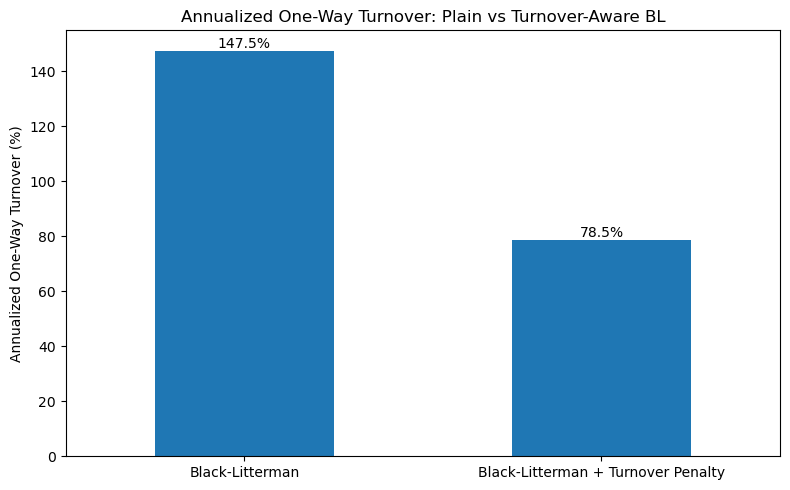

In [74]:
# BL Turnover Comparison

bl_turnover_plot = (turnover_summary.loc[["Black-Litterman","Black-Litterman + Turnover Penalty"], "Annualized_OneWay_Turnover_Approx"] * 100)

ax = bl_turnover_plot.plot(kind="bar",figsize=(8, 5))

ax.set_title("Annualized One-Way Turnover: Plain vs Turnover-Aware BL")

ax.set_ylabel("Annualized One-Way Turnover (%)")
ax.set_xlabel("")

for patch in ax.patches:
    height = patch.get_height()

    ax.annotate(f"{height:.1f}%",(patch.get_x() + patch.get_width()/2, height),ha="center",va="bottom")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [75]:
backtest_summary = (backtest_performance.join(turnover_summary,how="left"))

In [76]:
headline_columns = ["Annualized Return","Annualized Volatility","Sharpe Ratio","Sortino Ratio","Max Drawdown","CVaR 95%","Annualized_OneWay_Turnover_Approx","Annualized_Transaction_Cost_Approx"]

In [77]:
headline_backtest_summary = (backtest_summary[headline_columns].sort_values("Sharpe Ratio",ascending=False))

display(headline_backtest_summary)

,Annualized Return,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,CVaR 95%,Annualized_OneWay_Turnover_Approx,Annualized_Transaction_Cost_Approx
Strategy,,,,,,,,
Maximum Sharpe,0.095694,0.087032,0.914340,1.459935,-0.221346,-0.053178,0.432077,0.000864
Historical Mean-Variance,0.119921,0.129305,0.817075,1.262569,-0.258839,-0.080041,0.542976,0.001086
Black-Litterman,0.090974,0.110900,0.692613,1.100306,-0.138804,-0.066215,1.474886,0.002950
CVaR,0.048505,0.047253,0.689122,1.114612,-0.088174,-0.027543,0.316657,0.000633
Black-Litterman + Turnover Penalty,0.088278,0.109026,0.680735,1.066361,-0.139009,-0.066345,0.785067,0.001570
Equal Weight,0.064877,0.081513,0.611396,0.924816,-0.175557,-0.048194,0.075153,0.000150
Risk Parity,0.043807,0.050868,0.545927,0.816272,-0.133538,-0.030489,0.104795,0.000210
Minimum Variance,0.026523,0.033516,0.301030,0.412914,-0.094641,-0.020687,0.166355,0.000333


**Walk-forward performance.** No single optimiser dominates every metric.

Maximum Sharpe achieves the highest realised Sharpe ratio, while Historical Mean–Variance produces the highest annualised return but also the deepest drawdown. CVaR provides strong downside protection at the cost of much lower returns.

Plain BL improves annualised return, Sharpe ratio and maximum drawdown relative to Equal Weight, but does so with higher volatility and substantially greater turnover.

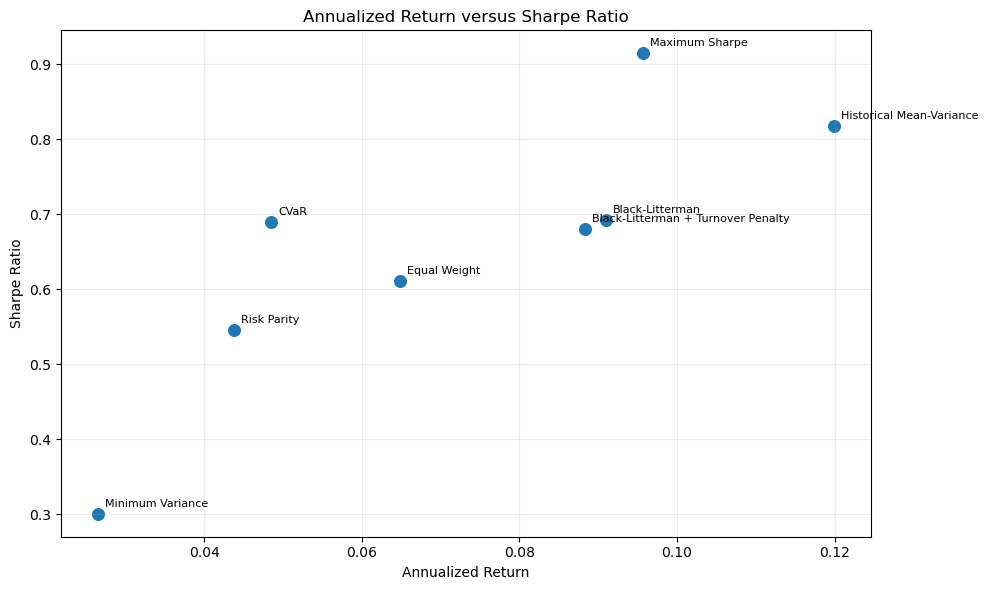

In [78]:
# Annualized Return vs Sharpe Ratio

return_sharpe_plot = (headline_backtest_summary[["Annualized Return","Sharpe Ratio"]].copy())

ax = return_sharpe_plot.plot.scatter(x="Annualized Return",y="Sharpe Ratio",figsize=(10, 6),s=70)

for strategy, row in return_sharpe_plot.iterrows():

    ax.annotate(strategy,(row["Annualized Return"],row["Sharpe Ratio"]),xytext=(5, 5),textcoords="offset points",fontsize=8)

ax.set_title("Annualized Return versus Sharpe Ratio")

ax.set_xlabel("Annualized Return")
ax.set_ylabel("Sharpe Ratio")

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

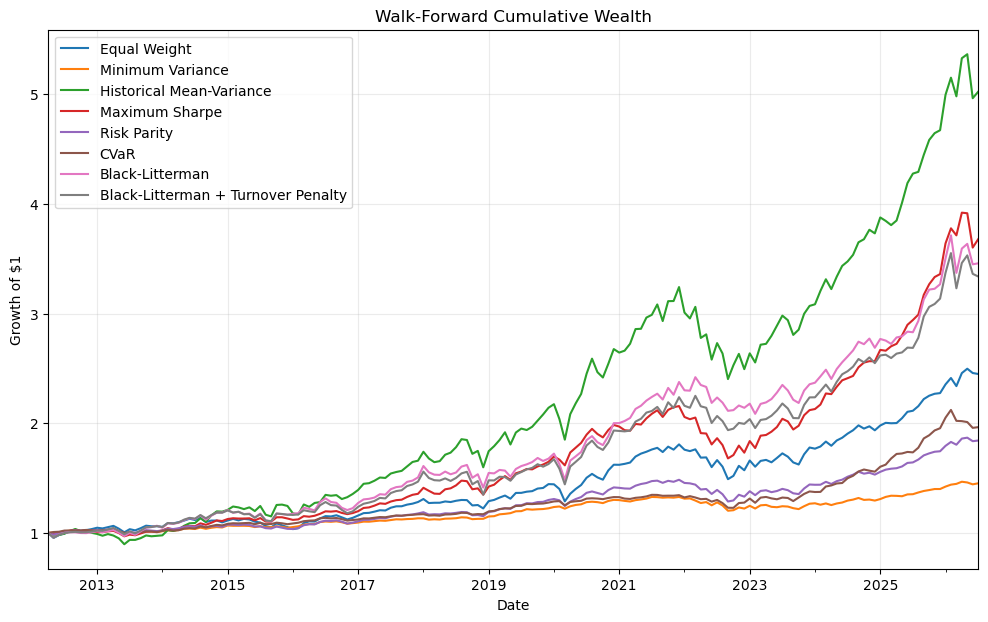

In [79]:
# WALK-FORWARD CUMULATIVE WEALTH
initial_date = (backtest_net_returns.index[0] - pd.offsets.MonthEnd(1))

cumulative_wealth = (1 + backtest_net_returns).cumprod()

# Add starting portfolio value = 1
initial_wealth = pd.DataFrame(1.0, index=[initial_date],columns=cumulative_wealth.columns)

cumulative_wealth = pd.concat([initial_wealth,cumulative_wealth])

ax = cumulative_wealth.plot(figsize=(12, 7))

ax.set_title("Walk-Forward Cumulative Wealth")

ax.set_ylabel("Growth of $1")

ax.set_xlabel("Date")

ax.grid(alpha=0.25)

plt.show()

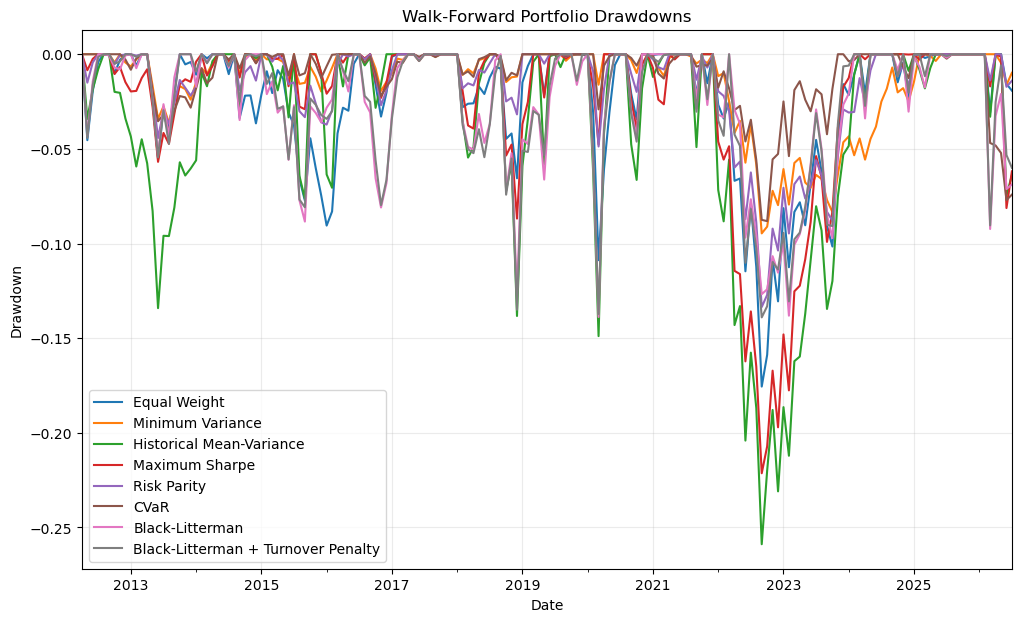

In [80]:
# WALK-FORWARD DRAWDOWNS
backtest_drawdowns = (cumulative_wealth / cumulative_wealth.cummax() - 1)

ax = backtest_drawdowns.plot(figsize=(12, 7))

ax.set_title("Walk-Forward Portfolio Drawdowns")

ax.set_ylabel("Drawdown")

ax.set_xlabel("Date")

ax.grid(alpha=0.25)

plt.show()

## View Efficacy and Portfolio Concentration

### Realised Black–Litterman View Outcomes

In [81]:
# WALK-FORWARD VIEW REALIZATION DIAGNOSTICS
view_realization_rows = []


for date, row in (backtest_rebalance_diagnostics.iterrows()):
    
    top_assets_t = (row["TopAssets"].split(","))

    bottom_assets_t = (row["BottomAssets"].split(","))

    # Next 3 months only
    future_returns = (asset_monthly_returns.loc[asset_monthly_returns.index > date,ASSETS].head(REBALANCE_FREQUENCY_MONTHS))

    if len(future_returns) < REBALANCE_FREQUENCY_MONTHS:
        continue

    # Compound each asset through the holding period
    asset_holding_returns = ((1 + future_returns).prod(axis=0) - 1)

    realized_top = float(asset_holding_returns[top_assets_t].mean())

    realized_bottom = float(asset_holding_returns[bottom_assets_t].mean())

    realized_spread = (realized_top - realized_bottom)

    # Q is annualized → convert to quarterly horizon
    expected_spread = (row["Q"] * REBALANCE_FREQUENCY_MONTHS / ANNUALIZATION_FACTOR)


    view_realization_rows.append({

        "RebalanceDate":
            date,

        "Expected3MSpread":
            expected_spread,

        "RealizedTop3Return":
            realized_top,

        "RealizedBottom3Return":
            realized_bottom,

        "RealizedTopBottomSpread":
            realized_spread,

        "ViewHit":
            realized_spread > 0,

        "ViewError":
            realized_spread
            - expected_spread,

        "ScoreGap":
            row["ScoreGap"]
    })


walkforward_view_realization = (pd.DataFrame(view_realization_rows).set_index("RebalanceDate"))

display(walkforward_view_realization.head())

,Expected3MSpread,RealizedTop3Return,RealizedBottom3Return,RealizedTopBottomSpread,ViewHit,ViewError,ScoreGap
RebalanceDate,,,,,,,
2012-04-30,0.013144,-0.003223,-0.029042,0.025819,True,0.012675,2.103008
2012-07-31,0.013763,0.000514,0.044956,-0.044442,False,-0.058205,2.202094
2012-10-31,0.012074,0.021925,0.038363,-0.016439,False,-0.028513,1.931880
2013-01-31,0.014545,0.033522,-0.027670,0.061192,True,0.046647,2.327252
2013-04-30,0.016146,-0.004626,-0.039125,0.034499,True,0.018353,2.583385


In [82]:
# WALK-FORWARD VIEW QUALITY SUMMARY
view_correlation = (walkforward_view_realization[["Expected3MSpread","RealizedTopBottomSpread"]].corr().iloc[0, 1])

score_realization_correlation = (walkforward_view_realization[["ScoreGap","RealizedTopBottomSpread"]].corr().iloc[0, 1])

view_quality_summary = pd.Series({"Number of Quarterly Views":len(walkforward_view_realization),
                                  "View Hit Rate":walkforward_view_realization["ViewHit"].mean(),
                                  "Mean Expected 3M Spread":walkforward_view_realization["Expected3MSpread"].mean(),
                                  "Mean Realized Top-Bottom Spread":walkforward_view_realization["RealizedTopBottomSpread"].mean(),
                                  "Median Realized Top-Bottom Spread":walkforward_view_realization["RealizedTopBottomSpread"].median(),
                                  "Expected vs Realized Correlation":view_correlation,
                                  "Score Gap vs Realized Correlation":score_realization_correlation,
                                  "Mean View Error":walkforward_view_realization["ViewError"].mean()})


display(view_quality_summary)

Number of Quarterly Views            57.000000
View Hit Rate                         0.684211
Mean Expected 3M Spread               0.014027
Mean Realized Top-Bottom Spread       0.020041
Median Realized Top-Bottom Spread     0.025819
Expected vs Realized Correlation      0.166647
Score Gap vs Realized Correlation     0.166647
Mean View Error                       0.006015
dtype: float64

**Signal-efficacy result.** Across 57 quarterly views, the Top-3 basket outperformed the Bottom-3 basket approximately **68.4% of the time**. The mean realised three-month spread was about **2.00%**, compared with an average expected spread of about **1.40%**.

However, the expected-versus-realised spread correlation is only about **0.17**. The signal therefore appears more useful for identifying the **direction of relative performance** than for forecasting its precise magnitude.

### Portfolio Concentration Through Time

In [83]:
# PORTFOLIO CONCENTRATION THROUGH TIME

concentration_rows = []


for date, weights_table in (BACKTEST_RESULTS["target_weights"].items()):

    for strategy, weights in (weights_table.iterrows()):
        w = (weights[ASSETS].astype(float))
        
        hhi = float(np.square(w).sum())

        effective_n = (1.0 / hhi)
        
        largest_weights = (w.sort_values(ascending=False))

        concentration_rows.append({"RebalanceDate":date,
                                   "Strategy":strategy,
                                   "MaxWeight":largest_weights.iloc[0],
                                   "Top3Weight":largest_weights.iloc[:3].sum(),
                                   "EffectiveN":effective_n,
                                   "ZeroWeightCount":(w <= 1e-8).sum(),
                                   "AtWeightCap":(w >= MAX_WEIGHT - 1e-6).sum()})

concentration_history = (pd.DataFrame(concentration_rows).set_index(["RebalanceDate","Strategy"]).sort_index())

In [84]:
bl_strategy_names = ["Black-Litterman", "Black-Litterman + Turnover Penalty"]

bl_concentration_summary = (
    concentration_history
    .reset_index()
    .query(
        "Strategy in @bl_strategy_names"
    )
    .groupby(
        "Strategy"
    )
    .agg({"MaxWeight":["mean","median","max" ], 
          "Top3Weight":["mean", "median", "max"], 
          "EffectiveN":["mean","median","min"],
          "AtWeightCap":"sum"}))


display(bl_concentration_summary)

MaxWeight                Top3Weight  \
                                        mean    median  max       mean   
Strategy                                                                 
Black-Litterman                     0.309184  0.352569  0.4   0.757659   
Black-Litterman + Turnover Penalty  0.311744  0.331442  0.4   0.726903   

                                                  EffectiveN            \
                                      median  max       mean    median   
Strategy                                                                 
Black-Litterman                     0.808975  1.0   4.976370  3.847306   
Black-Litterman + Turnover Penalty  0.750054  1.0   4.980994  4.381759   

                                             AtWeightCap  
                                         min         sum  
Strategy                                                  
Black-Litterman                     2.797328          20  
Black-Litterman + Turnover Penalty  2.924477           5

Plain BL remains relatively concentrated despite the diversified 12-asset universe. Its average effective number of assets is approximately five and the three largest positions account for roughly three-quarters of the portfolio.

Turnover regularisation does not materially change average Effective N, but it reduces the frequency with which an asset reaches the 40% cap from 20 instances to only 5. This is another practical benefit of the regularised implementation.

## Post-Optimisation Factor Attribution

In [85]:
FACTOR_HAC_LAGS = 3

def run_factor_regressions(return_df,factor_df,factor_cols=FACTOR_COLUMNS,hac_lags=3,annualization_periods=12):
    
    beta_rows = []
    tstat_rows = []
    summary_rows = []


    for strategy in return_df.columns:
        data = (pd.concat([return_df[strategy].rename("Dependent"),factor_df[factor_cols]],axis=1).dropna())

        if len(data) < (len(factor_cols) + 10):
            continue

        y = (data["Dependent"])

        X = (sm.add_constant(data[factor_cols],has_constant="add"))
        
        model = (sm.OLS(y,X).fit(cov_type="HAC",cov_kwds={"maxlags":hac_lags}))

        beta_row = {"Strategy":strategy}
        
        tstat_row = {"Strategy":strategy}

        for factor in factor_cols:

            beta_row[factor] = (model.params[factor])

            tstat_row[factor] = (model.tvalues[factor])


        alpha = (model.params["const"])

        beta_rows.append(beta_row)

        tstat_rows.append(tstat_row)

        summary_rows.append({

            "Strategy":strategy,

            "Alpha Monthly":alpha,

            "Alpha Annual Approx":alpha * annualization_periods,

            "Alpha t-stat":model.tvalues["const"],

            "R2":model.rsquared,

            "N":int(model.nobs)})


    betas = (pd.DataFrame(beta_rows).set_index("Strategy"))

    tstats = (pd.DataFrame(tstat_rows).set_index("Strategy"))

    summary = (pd.DataFrame(summary_rows).set_index("Strategy"))

    return (betas,tstats,summary)

In [86]:
backtest_excess_returns = (backtest_net_returns.sub(rf_monthly,axis=0))

In [87]:
backtest_factor_common_dates = (backtest_excess_returns.dropna(how="all").index.intersection(factor_monthly_excess_returns[FACTOR_COLUMNS].dropna().index))

backtest_excess_aligned = (backtest_excess_returns.reindex(backtest_factor_common_dates))

backtest_factors_aligned = (factor_monthly_excess_returns[FACTOR_COLUMNS].reindex(backtest_factor_common_dates))

In [88]:
combined_factor_check = pd.concat([backtest_excess_aligned,backtest_factors_aligned],axis=1)

if combined_factor_check.isna().any().any():
    raise ValueError("Missing values remain after factor alignment.")

print("Factor-model overlap:",len(backtest_factor_common_dates),"/",len(backtest_net_returns),"months")

Factor-model overlap: 171 / 171 months


In [89]:
(backtest_factor_betas,backtest_factor_tstats,backtest_factor_summary) = (run_factor_regressions(return_df=backtest_excess_aligned,factor_df=backtest_factors_aligned,factor_cols=FACTOR_COLUMNS,hac_lags=FACTOR_HAC_LAGS,annualization_periods=ANNUALIZATION_FACTOR))

In [90]:
print("Realized portfolio factor betas:")

display(backtest_factor_betas.round(3))


print("Factor beta t-statistics:")

display(backtest_factor_tstats.round(2))

print("Factor-adjusted performance:")

display(backtest_factor_summary.sort_values("Alpha Annual Approx",ascending=False).round(4))

Realized portfolio factor betas:


,Equity,Duration,Credit,Commodity
Strategy,,,,
Equal Weight,0.426,0.319,0.129,0.071
Minimum Variance,0.039,0.324,0.147,0.041
Historical Mean-Variance,0.784,0.108,-0.007,0.009
Maximum Sharpe,0.465,0.109,-0.141,0.056
Risk Parity,0.196,0.318,0.124,0.050
CVaR,0.073,0.306,0.152,0.009
Black-Litterman,0.671,0.022,-0.158,0.015
Black-Litterman + Turnover Penalty,0.657,0.075,-0.114,0.007


Factor beta t-statistics:


,Equity,Duration,Credit,Commodity
Strategy,,,,
Equal Weight,19.25,9.99,3.84,8.25
Minimum Variance,2.27,10.23,4.51,4.17
Historical Mean-Variance,11.16,1.01,-0.06,0.20
Maximum Sharpe,10.44,1.25,-1.39,1.39
Risk Parity,11.17,11.72,4.09,6.17
CVaR,2.04,6.43,2.57,0.42
Black-Litterman,8.30,0.18,-1.15,0.40
Black-Litterman + Turnover Penalty,8.11,0.64,-0.85,0.21


Factor-adjusted performance:


,Alpha Monthly,Alpha Annual Approx,Alpha t-stat,R2,N
Strategy,,,,,
Maximum Sharpe,0.0032,0.0383,2.5753,0.6477,171
Historical Mean-Variance,0.0024,0.0288,1.7206,0.7511,171
CVaR,0.0017,0.0209,1.9145,0.4450,171
Black-Litterman,0.0013,0.0162,1.0431,0.6549,171
Black-Litterman + Turnover Penalty,0.0011,0.0136,0.9602,0.6892,171
Risk Parity,0.0005,0.0054,1.3280,0.9059,171
Equal Weight,0.0004,0.0046,0.9482,0.9479,171
Minimum Variance,0.0002,0.0027,0.7660,0.8293,171


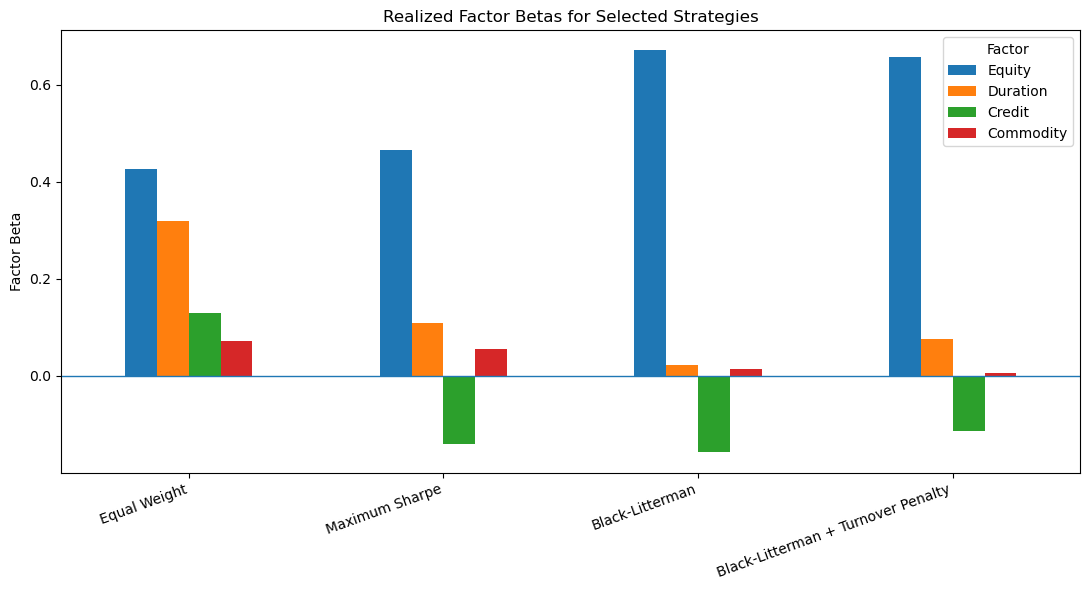

In [91]:
# Realized Factor-Beta Comparison

FACTOR_PLOT_STRATEGIES = [
    "Equal Weight",
    "Maximum Sharpe",
    "Black-Litterman",
    "Black-Litterman + Turnover Penalty"
]

factor_beta_plot = (backtest_factor_betas.loc[FACTOR_PLOT_STRATEGIES,FACTOR_COLUMNS])

ax = factor_beta_plot.plot(kind="bar",figsize=(11, 6))

ax.axhline(0,linewidth=1)

ax.set_title("Realized Factor Betas for Selected Strategies")

ax.set_ylabel("Factor Beta")
ax.set_xlabel("")

ax.legend(title="Factor")

plt.xticks(rotation=20,ha="right")

plt.tight_layout()
plt.show()

In [92]:
def calculate_risk_contributions(weights,covariance):
    
    assets = list(covariance.columns)

    w = (weights.reindex(assets).astype(float))

    sigma = (covariance.reindex(index=assets,columns=assets).astype(float))

    if w.isna().any():
        raise ValueError("Missing portfolio weights.")

    w_values = w.values
    sigma_values = sigma.values


    portfolio_variance = float(w_values @ sigma_values @ w_values)

    if portfolio_variance <= 0:
        raise ValueError("Portfolio variance must be positive.")

    marginal_variance = (sigma_values @ w_values)

    component_variance = (w_values * marginal_variance)

    risk_contribution = (component_variance / portfolio_variance)

    risk_table = pd.DataFrame({"Weight":w_values,"RiskContribution":risk_contribution}, index=assets)

    if not np.isclose(risk_table["RiskContribution"].sum(),1.0,atol=1e-8):
        raise ValueError("Risk contributions do not sum to one.")


    return risk_table

In [93]:
SLEEVE_MAP = {"Equity": ["SPY","QQQ","EFA","EEM"],
              "Rates": ["SHY","IEF","TIP"],
              "Credit": ["LQD","HYG"],
              "RealAssets": ["GLD","DBC"],
              "REIT": ["VNQ"]}

In [94]:
def aggregate_asset_table_to_sleeves(asset_table,sleeve_map=SLEEVE_MAP):

    result = pd.DataFrame(index=asset_table.index)

    for sleeve, assets in (sleeve_map.items()):
        result[sleeve] = (asset_table[assets].sum(axis=1))
        
    return result[list(sleeve_map.keys())]

In [95]:
walkforward_asset_capital_rows = []
walkforward_asset_risk_rows = []


for date, weights_table in (BACKTEST_RESULTS["target_weights"].items()):

    # Reconstruct covariance used by OUR walk-forward model
    sigma_t, _ = (estimate_covariance(returns=asset_monthly_excess_returns,as_of_date=date,window=ROLLING_WINDOW,method="ledoit_wolf",annualization_factor=ANNUALIZATION_FACTOR))

    for strategy, weights in (weights_table.iterrows()):

        w = (weights[ASSETS].astype(float))

        risk_table = (calculate_risk_contributions(weights=w,covariance=sigma_t))

        # Capital allocation
        capital_row = {"RebalanceDate":pd.Timestamp(date),
                       "Strategy":strategy}

        capital_row.update(w.to_dict())

        walkforward_asset_capital_rows.append(capital_row)
        
        # Risk allocation
        risk_row = {"RebalanceDate":pd.Timestamp(date),
                    "Strategy":strategy}

        risk_row.update(risk_table["RiskContribution"].to_dict())

        walkforward_asset_risk_rows.append(risk_row)

In [96]:
walkforward_asset_capital = (pd.DataFrame(walkforward_asset_capital_rows).set_index(["RebalanceDate","Strategy"]).sort_index())

walkforward_asset_risk = (pd.DataFrame(walkforward_asset_risk_rows).set_index(["RebalanceDate","Strategy"]).sort_index())

In [97]:
assert np.allclose(walkforward_asset_capital[ASSETS].sum(axis=1),1.0,atol=1e-6)

assert np.allclose(walkforward_asset_risk[ASSETS].sum(axis=1),1.0,atol=1e-6)

print("Walk-forward risk contribution validation passed.")

Walk-forward risk contribution validation passed.


In [98]:
walkforward_sleeve_capital = (aggregate_asset_table_to_sleeves(walkforward_asset_capital[ASSETS]))

walkforward_sleeve_risk = (aggregate_asset_table_to_sleeves(walkforward_asset_risk[ASSETS]))

In [99]:
average_sleeve_capital = (walkforward_sleeve_capital.groupby(level="Strategy").mean())

average_sleeve_risk = (walkforward_sleeve_risk.groupby(level="Strategy").mean())

risk_minus_capital = (average_sleeve_risk - average_sleeve_capital)

In [100]:
KEY_RISK_STRATEGIES = [
    "Equal Weight",
    "Maximum Sharpe",
    "CVaR",
    "Black-Litterman",
    "Black-Litterman + Turnover Penalty"
]

In [101]:
print("Average capital allocation by sleeve:")

display(average_sleeve_capital.loc[KEY_RISK_STRATEGIES].round(4))

print("Average risk contribution by sleeve:")

display(average_sleeve_risk.loc[KEY_RISK_STRATEGIES].round(4))

print("Risk contribution minus capital allocation:")

display(risk_minus_capital.loc[KEY_RISK_STRATEGIES].round(4))

Average capital allocation by sleeve:


,Equity,Rates,Credit,RealAssets,REIT
Strategy,,,,,
Equal Weight,0.3333,0.2500,0.1667,0.1667,0.0833
Maximum Sharpe,0.3653,0.3462,0.0766,0.2116,0.0002
CVaR,0.0584,0.6887,0.1369,0.1155,0.0005
Black-Litterman,0.4453,0.1438,0.0837,0.1931,0.1341
Black-Litterman + Turnover Penalty,0.4295,0.1561,0.0825,0.1978,0.1341


Average risk contribution by sleeve:


,Equity,Rates,Credit,RealAssets,REIT
Strategy,,,,,
Equal Weight,0.5383,0.0441,0.1138,0.1687,0.1350
Maximum Sharpe,0.6242,0.1349,0.0510,0.1894,0.0004
CVaR,0.0938,0.5513,0.1430,0.2109,0.0010
Black-Litterman,0.5244,0.0435,0.0495,0.1955,0.1871
Black-Litterman + Turnover Penalty,0.5250,0.0385,0.0473,0.1938,0.1953


Risk contribution minus capital allocation:


,Equity,Rates,Credit,RealAssets,REIT
Strategy,,,,,
Equal Weight,0.2050,-0.2059,-0.0528,0.0020,0.0517
Maximum Sharpe,0.2589,-0.2113,-0.0257,-0.0222,0.0002
CVaR,0.0354,-0.1374,0.0061,0.0954,0.0005
Black-Litterman,0.0791,-0.1003,-0.0341,0.0024,0.0529
Black-Litterman + Turnover Penalty,0.0955,-0.1176,-0.0352,-0.0040,0.0612


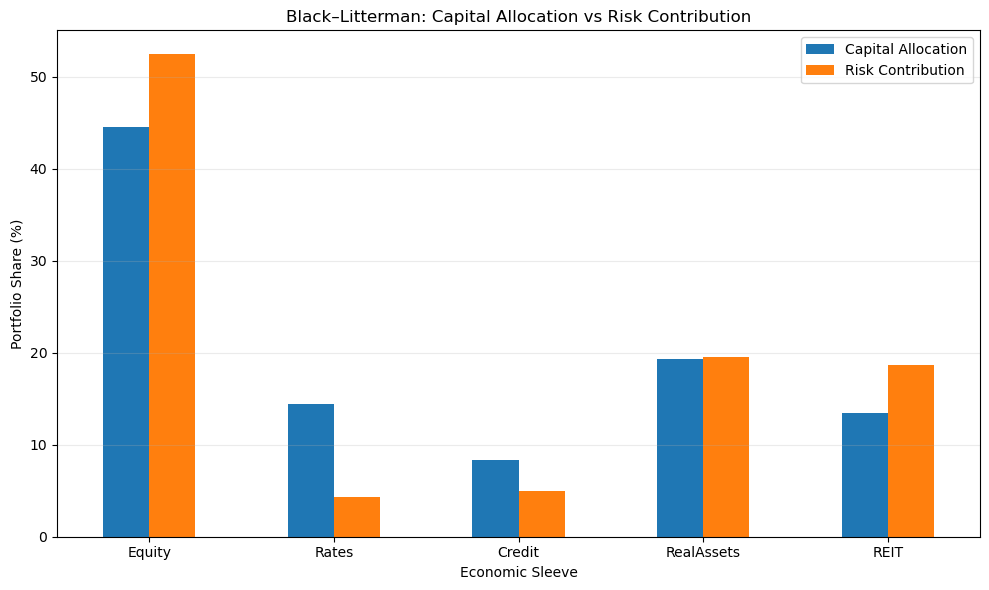

In [102]:
# Plain BL: Capital Allocation vs Risk Contribution

bl_capital_vs_risk = pd.DataFrame({"Capital Allocation":average_sleeve_capital.loc["Black-Litterman"],
                                   "Risk Contribution":average_sleeve_risk.loc["Black-Litterman"]})


ax = (bl_capital_vs_risk * 100).plot(kind="bar", figsize=(10, 6))

ax.set_title("Black–Litterman: Capital Allocation vs Risk Contribution")

ax.set_ylabel("Portfolio Share (%)")
ax.set_xlabel("Economic Sleeve")

ax.grid(axis="y",alpha=0.25)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Final Integrated Strategy Comparison

Performance alone does not determine whether a portfolio construction method is attractive. The final comparison therefore combines:

- realised return and downside risk;
- turnover and estimated transaction costs;
- concentration;
- realised factor exposures;
- factor-adjusted alpha; and
- economic capital and risk allocation.

This allows each optimiser to be evaluated as an investable portfolio rather than simply as an optimisation output.

In [103]:
# FINAL OPTIMIZER INFERENCE TABLE

SLEEVE_ORDER = list(SLEEVE_MAP.keys())

# 1. PERFORMANCE
performance_columns = [
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Sortino Ratio",
    "Max Drawdown",
    "CVaR 95%",
    "Annualized_OneWay_Turnover_Approx",
    "Annualized_Transaction_Cost_Approx"
]


final_performance_block = (backtest_summary[performance_columns].copy())

In [104]:
# 2. CONCENTRATION

final_effective_n = (concentration_history.reset_index().groupby("Strategy")["EffectiveN"].mean().rename("AverageEffectiveN"))

In [105]:
# 3. FACTOR EXPOSURES

final_factor_block = (backtest_factor_betas[FACTOR_COLUMNS].copy().rename(columns={factor: f"Beta_{factor}" for factor in FACTOR_COLUMNS}))

In [106]:
# 4. FACTOR-ADJUSTED PERFORMANCE
final_alpha_block = (backtest_factor_summary[["Alpha Annual Approx","Alpha t-stat","R2"]].copy())

In [107]:
# 5. CAPITAL AND RISK SLEEVES

final_capital_block = (average_sleeve_capital.copy().rename(columns={sleeve: f"Capital_{sleeve}" for sleeve in SLEEVE_ORDER}))

final_risk_block = (average_sleeve_risk.copy().rename(columns={sleeve: f"Risk_{sleeve}" for sleeve in SLEEVE_ORDER}))

In [108]:
optimizer_inference_full = (final_performance_block.join(final_effective_n,how="left").join(final_factor_block,how="left").join(final_alpha_block,how="left").join(final_capital_block,how="left").join(final_risk_block,how="left"))

In [109]:
capital_columns = [f"Capital_{sleeve}" for sleeve in SLEEVE_ORDER]

risk_columns = [f"Risk_{sleeve}" for sleeve in SLEEVE_ORDER]

optimizer_inference_full["DominantCapitalSleeve"] = (optimizer_inference_full[capital_columns].idxmax(axis=1).str.replace("Capital_","",regex=False))

optimizer_inference_full["DominantRiskSleeve"] = (optimizer_inference_full[risk_columns].idxmax(axis=1).str.replace("Risk_","",regex=False))

In [110]:
compact_columns = [
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Max Drawdown",
    "CVaR 95%",

    "Annualized_OneWay_Turnover_Approx",
    "Annualized_Transaction_Cost_Approx",

    "AverageEffectiveN",

    "Beta_Equity",
    "Beta_Duration",
    "Beta_Credit",
    "Beta_Commodity",

    "Alpha Annual Approx",
    "Alpha t-stat",
    "R2",

    "DominantCapitalSleeve",
    "DominantRiskSleeve"
]


optimizer_inference_compact = (optimizer_inference_full[compact_columns].sort_values("Sharpe Ratio",ascending=False))

display(optimizer_inference_compact.round(4))

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,CVaR 95%,Annualized_OneWay_Turnover_Approx,Annualized_Transaction_Cost_Approx,AverageEffectiveN,Beta_Equity,Beta_Duration,Beta_Credit,Beta_Commodity,Alpha Annual Approx,Alpha t-stat,R2,DominantCapitalSleeve,DominantRiskSleeve
Strategy,,,,,,,,,,,,,,,,,
Maximum Sharpe,0.0957,0.0870,0.9143,-0.2213,-0.0532,0.4321,0.0009,3.6226,0.4653,0.1090,-0.1407,0.0557,0.0383,2.5753,0.6477,Equity,Equity
Historical Mean-Variance,0.1199,0.1293,0.8171,-0.2588,-0.0800,0.5430,0.0011,2.8985,0.7839,0.1081,-0.0072,0.0088,0.0288,1.7206,0.7511,Equity,Equity
Black-Litterman,0.0910,0.1109,0.6926,-0.1388,-0.0662,1.4749,0.0029,4.9764,0.6709,0.0224,-0.1578,0.0148,0.0162,1.0431,0.6549,Equity,Equity
CVaR,0.0485,0.0473,0.6891,-0.0882,-0.0275,0.3167,0.0006,3.1637,0.0733,0.3055,0.1519,0.0086,0.0209,1.9145,0.4450,Rates,Rates
Black-Litterman + Turnover Penalty,0.0883,0.1090,0.6807,-0.1390,-0.0663,0.7851,0.0016,4.9810,0.6570,0.0752,-0.1139,0.0068,0.0136,0.9602,0.6892,Equity,Equity
Equal Weight,0.0649,0.0815,0.6114,-0.1756,-0.0482,0.0752,0.0002,12.0000,0.4260,0.3187,0.1288,0.0711,0.0046,0.9482,0.9479,Equity,Equity
Risk Parity,0.0438,0.0509,0.5459,-0.1335,-0.0305,0.1048,0.0002,6.8910,0.1965,0.3182,0.1239,0.0504,0.0054,1.3280,0.9059,Rates,Equity
Minimum Variance,0.0265,0.0335,0.3010,-0.0946,-0.0207,0.1664,0.0003,3.8657,0.0393,0.3238,0.1473,0.0405,0.0027,0.7660,0.8293,Rates,Rates


In [111]:
BL_COMPARISON_STRATEGIES = [
    "Equal Weight",
    "Black-Litterman",
    "Black-Litterman + Turnover Penalty"
]

bl_final_comparison = (optimizer_inference_compact.loc[BL_COMPARISON_STRATEGIES])

display(bl_final_comparison.round(4))

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,CVaR 95%,Annualized_OneWay_Turnover_Approx,Annualized_Transaction_Cost_Approx,AverageEffectiveN,Beta_Equity,Beta_Duration,Beta_Credit,Beta_Commodity,Alpha Annual Approx,Alpha t-stat,R2,DominantCapitalSleeve,DominantRiskSleeve
Strategy,,,,,,,,,,,,,,,,,
Equal Weight,0.0649,0.0815,0.6114,-0.1756,-0.0482,0.0752,0.0002,12.0000,0.4260,0.3187,0.1288,0.0711,0.0046,0.9482,0.9479,Equity,Equity
Black-Litterman,0.0910,0.1109,0.6926,-0.1388,-0.0662,1.4749,0.0029,4.9764,0.6709,0.0224,-0.1578,0.0148,0.0162,1.0431,0.6549,Equity,Equity
Black-Litterman + Turnover Penalty,0.0883,0.1090,0.6807,-0.1390,-0.0663,0.7851,0.0016,4.9810,0.6570,0.0752,-0.1139,0.0068,0.0136,0.9602,0.6892,Equity,Equity


### Final Black–Litterman inference

Relative to Equal Weight, plain Black–Litterman increases annualised return from approximately **6.49% to 9.10%**, raises the Sharpe ratio from **0.61 to 0.69**, and improves maximum drawdown from about **-17.6% to -13.9%**.

The main weakness is turnover: annualised one-way turnover is approximately **147.5%**. 

Adding the turnover penalty reduces annualised one-way turnover to approximately **78.5%**, while annualised return declines only from **9.10% to 8.83%** and Sharpe from **0.693 to 0.681**.

For this reason, plain BL provides the cleaner test of whether the systematic views add value, while **Black–Litterman + Turnover Penalty is the preferred practical implementation**.

## Analysis to be shown in report

In [112]:
REPORT_PERFORMANCE_COLUMNS = [
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Max Drawdown",
    "CVaR 95%",
    "Annualized_OneWay_Turnover_Approx"
]

report_performance_table = (optimizer_inference_full[REPORT_PERFORMANCE_COLUMNS].sort_values("Sharpe Ratio",ascending=False))

display(report_performance_table.round(4))

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,CVaR 95%,Annualized_OneWay_Turnover_Approx
Strategy,,,,,,
Maximum Sharpe,0.0957,0.0870,0.9143,-0.2213,-0.0532,0.4321
Historical Mean-Variance,0.1199,0.1293,0.8171,-0.2588,-0.0800,0.5430
Black-Litterman,0.0910,0.1109,0.6926,-0.1388,-0.0662,1.4749
CVaR,0.0485,0.0473,0.6891,-0.0882,-0.0275,0.3167
Black-Litterman + Turnover Penalty,0.0883,0.1090,0.6807,-0.1390,-0.0663,0.7851
Equal Weight,0.0649,0.0815,0.6114,-0.1756,-0.0482,0.0752
Risk Parity,0.0438,0.0509,0.5459,-0.1335,-0.0305,0.1048
Minimum Variance,0.0265,0.0335,0.3010,-0.0946,-0.0207,0.1664


In [113]:
# signal efficiency
report_signal_table = pd.Series({"Quarterly Views":len(walkforward_view_realization),
                                 "Hit Rate":walkforward_view_realization["ViewHit"].mean(),
                                 "Mean Expected 3M Spread":walkforward_view_realization["Expected3MSpread"].mean(),
                                 "Mean Realized 3M Spread":walkforward_view_realization["RealizedTopBottomSpread"].mean(),
                                 "Expected vs Realized Correlation":view_correlation})

display(report_signal_table.round(4))

Quarterly Views                     57.0000
Hit Rate                             0.6842
Mean Expected 3M Spread              0.0140
Mean Realized 3M Spread              0.0200
Expected vs Realized Correlation     0.1666
dtype: float64

In [114]:
# Plain BL vs Turnover penalized BL
BL_IMPLEMENTATION_COLUMNS = [
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Max Drawdown",
    "Annualized_OneWay_Turnover_Approx",
    "Annualized_Transaction_Cost_Approx",
    "AverageEffectiveN"
]


report_bl_comparison = (optimizer_inference_full.loc[["Black-Litterman","Black-Litterman + Turnover Penalty"],BL_IMPLEMENTATION_COLUMNS])

display(report_bl_comparison.round(4))

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Annualized_OneWay_Turnover_Approx,Annualized_Transaction_Cost_Approx,AverageEffectiveN
Strategy,,,,,,,
Black-Litterman,0.0910,0.1109,0.6926,-0.1388,1.4749,0.0029,4.9764
Black-Litterman + Turnover Penalty,0.0883,0.1090,0.6807,-0.1390,0.7851,0.0016,4.9810


In [115]:
# Factor Attribution
FACTOR_REPORT_STRATEGIES = [
    "Equal Weight",
    "Maximum Sharpe",
    "Black-Litterman",
    "Black-Litterman + Turnover Penalty"
]


report_factor_table = (optimizer_inference_full.loc[FACTOR_REPORT_STRATEGIES,["Beta_Equity","Beta_Duration","Beta_Credit","Beta_Commodity","Alpha Annual Approx","Alpha t-stat","R2"]])

display(report_factor_table.round(4))

,Beta_Equity,Beta_Duration,Beta_Credit,Beta_Commodity,Alpha Annual Approx,Alpha t-stat,R2
Strategy,,,,,,,
Equal Weight,0.4260,0.3187,0.1288,0.0711,0.0046,0.9482,0.9479
Maximum Sharpe,0.4653,0.1090,-0.1407,0.0557,0.0383,2.5753,0.6477
Black-Litterman,0.6709,0.0224,-0.1578,0.0148,0.0162,1.0431,0.6549
Black-Litterman + Turnover Penalty,0.6570,0.0752,-0.1139,0.0068,0.0136,0.9602,0.6892


In [116]:
# Economic Risk decomposition
RISK_REPORT_STRATEGIES = [
    "Equal Weight",
    "Black-Litterman",
    "Black-Litterman + Turnover Penalty"
]


report_risk_table = (average_sleeve_risk.loc[RISK_REPORT_STRATEGIES])

display(report_risk_table.round(4))

,Equity,Rates,Credit,RealAssets,REIT
Strategy,,,,,
Equal Weight,0.5383,0.0441,0.1138,0.1687,0.1350
Black-Litterman,0.5244,0.0435,0.0495,0.1955,0.1871
Black-Litterman + Turnover Penalty,0.5250,0.0385,0.0473,0.1938,0.1953
